# MOMENTS Goal: Language-Only vs Vision-Only Results

This is a standalone viewer for the current Qwen2 MOMENTS results. It does not modify or depend on `figures_and_results_processing.ipynb`.

The default comparison uses the matched `ap_ig_steps=5` archives: `qwen2-7b-vl-instruct_language_only_nap_ig=5`, `qwen2-7b-vl-instruct_vision_only_nap_ig=5`, and `qwen2-7b-vl-instruct_both_nap_ig=5`.

This notebook also reads the Table-5-style sweep outputs under `data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/table5_sweep/` when they are available.

It now also includes a MOMENTS-specific prompt table and appendix-style backpatching figures so the notebook can mirror the paper's analysis layout at the single-task level.

## How to read this notebook

This analysis adapts the circuit-comparison logic of Nikankin et al. (2025), *Same Task, Different Circuits*, to the MOMENTS goal task. The paper asks whether a VLM solves an analogous task through one shared circuit or through modality-specific circuits with comparable roles.

For this dataset, the clean input is a video frame plus a transcript-based goal question. The counterfactuals isolate the manipulated modality: language-only changes the transcript while keeping the image fixed; vision-only changes the image while keeping the transcript fixed; both changes both. The text-only `--language_only` runs are controls, not multimodal evidence.

The central questions to answer are:
- Do language and vision conditions retain faithfulness at similar circuit sizes?
- Do their high-attribution nodes occur in the same layers and hooks, or are they largely disjoint?
- If the nodes differ, do the layer-level patterns still suggest similar computational roles?
- Does the multimodal `both` condition require a combined or distinct circuit relative to the isolated perturbations?
- Can the MOMENTS task reproduce the paper's analysis structure even when the benchmark is narrower than the original five-task setting?

A result supports modality-specific mechanisms if the language and vision curves are both meaningful but their top hooks and attribution profiles have low overlap. A result supports shared mechanisms if the same hooks and layers dominate both conditions and their faithfulness curves are similar. Either conclusion requires checking the perturbation validity, row counts, token-length alignment, and baseline behavior first.

In [19]:
print('Paper: https://arxiv.org/abs/2506.09047')
print('Interpretation rule: faithfulness measures circuit sufficiency, while attribution overlap measures circuit similarity; neither alone proves a mechanism.')

Paper: https://arxiv.org/abs/2506.09047
Interpretation rule: faithfulness measures circuit sufficiency, while attribution overlap measures circuit similarity; neither alone proves a mechanism.


In [20]:
from pathlib import Path
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

# Support launching Jupyter from either this nested repo or the thesis repo root.
if (Path('data/moments_goal/results')).exists():
    REPO_ROOT = Path('.')
elif (Path('reproducing_code/vlm-circuits-analysis/data/moments_goal/results')).exists():
    REPO_ROOT = Path('reproducing_code/vlm-circuits-analysis')
else:
    REPO_ROOT = Path('.')
RESULTS_ROOT = REPO_ROOT / 'data/moments_goal/results'
LANGUAGE_DIR = RESULTS_ROOT / 'qwen2-7b-vl-instruct_language_only_nap_ig=5'
VISION_DIR = RESULTS_ROOT / 'qwen2-7b-vl-instruct_vision_only_nap_ig=5'
BOTH_DIR = RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_nap_ig=5'
OUTPUT_DIR = REPO_ROOT / 'figures/moments_language_vision_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS = {
    'language_only_l_view': {
        'label': 'Counterfactual mode: Language only, L view retained',
        'faithfulness': LANGUAGE_DIR / 'faithfulness_LD_l_node_circuit.pt',
        'scores': LANGUAGE_DIR / 'node_scores/nap_ig_l_ig=5_metric=LD.pt',
    },
    'language_only_vl_view': {
        'label': 'Counterfactual mode: Language only, VL view retained',
        'faithfulness': LANGUAGE_DIR / 'faithfulness_LD_vl_node_circuit.pt',
        'scores': LANGUAGE_DIR / 'node_scores/nap_ig_vl_ig=5_metric=LD.pt',
    },
    'vision_only_l_view': {
        'label': 'Counterfactual mode: Vision only, L view retained',
        'faithfulness': VISION_DIR / 'faithfulness_LD_l_node_circuit.pt',
        'scores': VISION_DIR / 'node_scores/nap_ig_l_ig=5_metric=LD.pt',
    },
    'vision_only_vl_view': {
        'label': 'Counterfactual mode: Vision only, VL view retained',
        'faithfulness': VISION_DIR / 'faithfulness_LD_vl_node_circuit.pt',
        'scores': VISION_DIR / 'node_scores/nap_ig_vl_ig=5_metric=LD.pt',
    },
    'both_multimodal': {
        'label': 'Counterfactual mode: Both (multimodal), VL view retained',
        'faithfulness': BOTH_DIR / 'faithfulness_LD_vl_node_circuit.pt',
        'scores': BOTH_DIR / 'node_scores/nap_ig_vl_ig=5_metric=LD.pt',
    },
    'both_text_only': {
        'label': 'Counterfactual mode: Both (text only), L view retained',
        'faithfulness': BOTH_DIR / 'faithfulness_LD_l_node_circuit.pt',
        'scores': BOTH_DIR / 'node_scores/nap_ig_l_ig=5_metric=LD.pt',
    },
}

for name, result in RESULTS.items():
    print(name)
    print('  faithfulness:', result['faithfulness'], result['faithfulness'].exists())
    print('  scores:', result['scores'], result['scores'].exists())

def faithfulness_is_complete(path):
    if not path.exists():
        return False
    _, _, completed = torch.load(path, weights_only=True)
    # Only the diagonal stores completion status for each requested checkpoint.
    return bool(completed.detach().cpu().bool().diag().all().item())

AVAILABLE_RESULTS = {
    name: result for name, result in RESULTS.items()
    if result['faithfulness'].exists()
    and result['scores'].exists()
    and faithfulness_is_complete(result['faithfulness'])
}
print('Available complete conditions:', list(AVAILABLE_RESULTS))
print('Incomplete conditions are intentionally excluded until all faithfulness checkpoints are complete.')
if not AVAILABLE_RESULTS:
    raise FileNotFoundError(
        f'No complete result sets were found. Copy the completed .pt files from Snellius into {RESULTS_ROOT}/qwen2-7b-vl-instruct* and rerun this cell.'
    )

language_only_l_view
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/faithfulness_LD_l_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/node_scores/nap_ig_l_ig=5_metric=LD.pt True
language_only_vl_view
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/faithfulness_LD_vl_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/node_scores/nap_ig_vl_ig=5_metric=LD.pt True
vision_only_l_view
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/faithfulness_LD_l_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/node_scores/nap_ig_l_ig=5_metric=LD.pt True
vision_only_vl_view
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/faithfulness_LD_vl_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-i

In [21]:
MODE_TITLES = {
      'language_only': 'Counterfactual mode: Language only',
      'vision_only': 'Counterfactual mode: Vision only',
      'both_multimodal': 'Counterfactual mode: Both (multimodal)',
  }

## Faithfulness curves

Faithfulness is the normalized LD circuit-ablation score, not a probability. Values below zero or above one can occur.

In [22]:
faithfulness_tables = {}
for name, result in AVAILABLE_RESULTS.items():
    percentages, values, completed = torch.load(result['faithfulness'], weights_only=True)
    percentages = list(percentages)
    values = values.detach().float().cpu().diag().tolist()
    completed = completed.detach().cpu().diag().tolist()
    faithfulness_tables[name] = pd.DataFrame({
        'condition': result['label'],
        'circuit_fraction': percentages,
        'circuit_percent': [100 * x for x in percentages],
        'faithfulness_LD': values,
        'completed': completed,
    })
if not faithfulness_tables:
    raise RuntimeError('No faithfulness tables were loaded; inspect AVAILABLE_RESULTS above.')
faithfulness = pd.concat(faithfulness_tables.values(), ignore_index=True)
display(faithfulness)

,condition,circuit_fraction,circuit_percent,faithfulness_LD,completed
0,"Counterfactual mode: Language only, L view retained",0.000,0.000000,0.000000,True
1,"Counterfactual mode: Language only, L view retained",0.001,0.100000,-0.004969,True
2,"Counterfactual mode: Language only, L view retained",0.005,0.500000,0.005925,True
3,"Counterfactual mode: Language only, L view retained",0.010,1.000000,-0.024753,True
4,"Counterfactual mode: Language only, L view retained",0.020,2.000000,0.004952,True
...,...,...,...,...,...
157,"Counterfactual mode: Both (text only), L view retained",0.200,20.000000,-0.288830,True
158,"Counterfactual mode: Both (text only), L view retained",0.300,30.000001,-2.866316,True
159,"Counterfactual mode: Both (text only), L view retained",0.500,50.000000,0.431082,True
160,"Counterfactual mode: Both (text only), L view retained",0.700,69.999999,0.433128,True


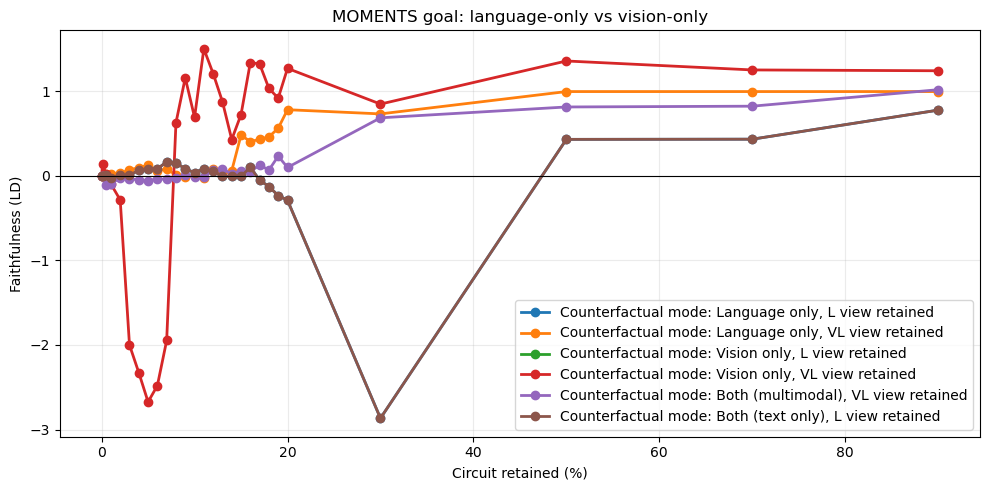

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, table in faithfulness_tables.items():
    ax.plot(table['circuit_percent'], table['faithfulness_LD'], marker='o', linewidth=2, label=RESULTS[name]['label'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Circuit retained (%)')
ax.set_ylabel('Faithfulness (LD)')
ax.set_title('MOMENTS goal: language-only vs vision-only')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'faithfulness_language_vs_vision.png', dpi=200, bbox_inches='tight')
plt.show()

## What to look for in the faithfulness plot

The x-axis is the percentage of nodes retained in the circuit; the y-axis is normalized LD faithfulness. A curve that rises quickly indicates that a small discovered circuit is sufficient for the evaluation condition. A curve that stays near zero or is unstable means that the discovered attribution scores do not identify a compact, reliably sufficient circuit under this evaluation.

Compare the language-only and vision-only curves descriptively, not by assuming that the highest point must be the answer. Similar curve shapes would suggest comparable circuit sufficiency; different shapes would suggest modality-dependent circuit organization or different perturbation difficulty. Negative or greater-than-one values are possible for this normalized metric and should be reported as diagnostic behavior, not as probabilities.

For the `both` conditions, ask whether the multimodal curve resembles one isolated modality, combines both patterns, or behaves differently. This is evidence about the circuit used by the model for this counterfactual, not direct evidence that the model understood the transcript semantically.

## Attribution by layer

The saved node scores are position-specific. This summarizes each hook by maximum and mean absolute attribution, grouped by transformer layer.

In [24]:
def attribution_table(scores_path):
    scores = torch.load(scores_path, weights_only=True)
    rows = []
    for hook, tensor in scores.items():
        tensor = tensor.detach().float().cpu().abs()
        match = re.search(r'blocks\.(\d+)\.', str(hook))
        if match is None:
            continue
        rows.append({
            'hook': str(hook),
            'layer': int(match.group(1)),
            'max_abs_score': float(tensor.max()),
            'mean_abs_score': float(tensor.mean()),
            'num_values': tensor.numel(),
        })
    return pd.DataFrame(rows).sort_values(['layer', 'hook']).reset_index(drop=True)

attributions = {name: attribution_table(result['scores']) for name, result in AVAILABLE_RESULTS.items()}
for name, table in attributions.items():
    print(RESULTS[name]['label'])
    display(table.sort_values('max_abs_score', ascending=False).head(15))

Counterfactual mode: Language only, L view retained


,hook,layer,max_abs_score,mean_abs_score,num_values
3,blocks.1.mlp.hook_post,1,0.015577,0.000002,1970176
55,blocks.27.mlp.hook_post,27,0.013509,0.000002,1970176
5,blocks.2.mlp.hook_post,2,0.007471,0.000003,1970176
1,blocks.0.mlp.hook_post,0,0.004682,0.000005,1970176
35,blocks.17.mlp.hook_post,17,0.004423,0.000011,1970176
19,blocks.9.mlp.hook_post,9,0.004003,0.000012,1970176
45,blocks.22.mlp.hook_post,22,0.003468,0.000003,1970176
9,blocks.4.mlp.hook_post,4,0.003451,0.000007,1970176
21,blocks.10.mlp.hook_post,10,0.003354,0.000015,1970176
39,blocks.19.mlp.hook_post,19,0.003212,0.000005,1970176


Counterfactual mode: Language only, VL view retained


,hook,layer,max_abs_score,mean_abs_score,num_values
55,blocks.27.mlp.hook_post,27,0.010266,5.985090e-07,3902464
0,blocks.0.attn.hook_z,0,0.007952,8.150588e-06,738304
3,blocks.1.mlp.hook_post,1,0.007369,9.340860e-07,3902464
19,blocks.9.mlp.hook_post,9,0.006200,7.448882e-06,3902464
7,blocks.3.mlp.hook_post,3,0.005192,2.757092e-06,3902464
35,blocks.17.mlp.hook_post,17,0.004868,5.477955e-06,3902464
45,blocks.22.mlp.hook_post,22,0.004692,1.033305e-06,3902464
9,blocks.4.mlp.hook_post,4,0.004568,4.101089e-06,3902464
5,blocks.2.mlp.hook_post,2,0.004386,1.767848e-06,3902464
1,blocks.0.mlp.hook_post,0,0.004081,2.724001e-06,3902464


Counterfactual mode: Vision only, L view retained


...

,hook,layer,max_abs_score,mean_abs_score,num_values
0,blocks.0.attn.hook_z,0,0.004155,2.065016e-06,738304
19,blocks.9.mlp.hook_post,9,0.003367,4.552091e-06,3902464
55,blocks.27.mlp.hook_post,27,0.003286,2.111609e-07,3902464
5,blocks.2.mlp.hook_post,2,0.003055,8.479871e-07,3902464
9,blocks.4.mlp.hook_post,4,0.002402,1.810549e-06,3902464
23,blocks.11.mlp.hook_post,11,0.002097,5.383941e-06,3902464
7,blocks.3.mlp.hook_post,3,0.001868,1.194673e-06,3902464
3,blocks.1.mlp.hook_post,1,0.001749,6.895742e-07,3902464
13,blocks.6.mlp.hook_post,6,0.001703,4.267790e-06,3902464
2,blocks.1.attn.hook_z,1,0.001585,2.152297e-06,738304


Counterfactual mode: Both (multimodal), VL view retained


,hook,layer,max_abs_score,mean_abs_score,num_values
55,blocks.27.mlp.hook_post,27,0.010439,6.171664e-07,3902464
0,blocks.0.attn.hook_z,0,0.007952,9.823902e-06,738304
3,blocks.1.mlp.hook_post,1,0.007426,1.525096e-06,3902464
19,blocks.9.mlp.hook_post,9,0.006212,1.067907e-05,3902464
7,blocks.3.mlp.hook_post,3,0.005193,3.698847e-06,3902464
45,blocks.22.mlp.hook_post,22,0.004632,1.249491e-06,3902464
9,blocks.4.mlp.hook_post,4,0.004568,5.476330e-06,3902464
35,blocks.17.mlp.hook_post,17,0.004505,6.578179e-06,3902464
5,blocks.2.mlp.hook_post,2,0.004386,2.452490e-06,3902464
1,blocks.0.mlp.hook_post,0,0.004097,3.887377e-06,3902464


Counterfactual mode: Both (text only), L view retained


,hook,layer,max_abs_score,mean_abs_score,num_values
3,blocks.1.mlp.hook_post,1,0.015577,0.000002,1970176
55,blocks.27.mlp.hook_post,27,0.013509,0.000002,1970176
5,blocks.2.mlp.hook_post,2,0.007471,0.000003,1970176
1,blocks.0.mlp.hook_post,0,0.004682,0.000005,1970176
35,blocks.17.mlp.hook_post,17,0.004423,0.000011,1970176
19,blocks.9.mlp.hook_post,9,0.004003,0.000012,1970176
45,blocks.22.mlp.hook_post,22,0.003468,0.000003,1970176
9,blocks.4.mlp.hook_post,4,0.003451,0.000007,1970176
21,blocks.10.mlp.hook_post,10,0.003354,0.000015,1970176
39,blocks.19.mlp.hook_post,19,0.003212,0.000005,1970176


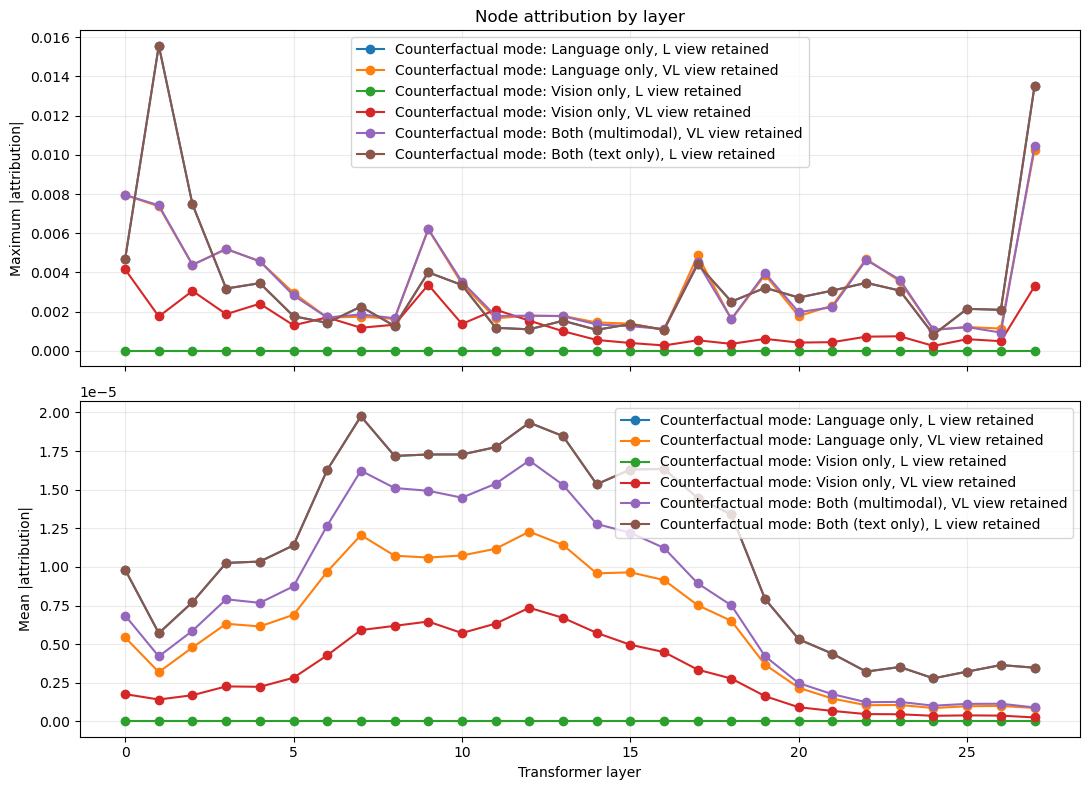

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for name, table in attributions.items():
    by_layer = table.groupby('layer', as_index=False).agg(max_abs_score=('max_abs_score', 'max'), mean_abs_score=('mean_abs_score', 'mean'))
    axes[0].plot(by_layer['layer'], by_layer['max_abs_score'], marker='o', label=RESULTS[name]['label'])
    axes[1].plot(by_layer['layer'], by_layer['mean_abs_score'], marker='o', label=RESULTS[name]['label'])
axes[0].set_ylabel('Maximum |attribution|')
axes[1].set_ylabel('Mean |attribution|')
axes[1].set_xlabel('Transformer layer')
axes[0].set_title('Node attribution by layer')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'attribution_by_layer_language_vs_vision.png', dpi=200, bbox_inches='tight')
plt.show()

## What to look for in the layer plot

The maximum curve highlights possible specialized nodes, while the mean curve is less sensitive to one extreme feature. If language and vision peaks occur in different layers or hooks, that is consistent with modality-specific processing. If they peak in similar layers but use different hooks, that may indicate similar computational stages with modality-specific representations. If both maxima and means align, that is stronger evidence for shared organization, although it still does not establish functional equivalence.

The paper emphasizes that modality-specific circuits can be largely disjoint while implementing analogous functions. Therefore, do not treat low hook overlap as failure: inspect whether the layer-level profiles and faithfulness behavior remain functionally similar. The next analysis step for a strong claim is an explicit top-k overlap/Jaccard or intersection analysis, ideally with a random-overlap baseline.

## Top nodes and exports

Use these tables to inspect the hooks contributing most strongly in each condition. A high maximum alone is not evidence of a stable circuit; compare maxima, means, and overlap between conditions.

In [26]:
top_nodes = []
for name, table in attributions.items():
    top = table.sort_values('max_abs_score', ascending=False).head(20).copy()
    top.insert(0, 'condition', RESULTS[name]['label'])
    top_nodes.append(top)
top_nodes = pd.concat(top_nodes, ignore_index=True)
display(top_nodes)

faithfulness.to_csv(OUTPUT_DIR / 'faithfulness_language_vs_vision.csv', index=False)
top_nodes.to_csv(OUTPUT_DIR / 'top_nodes_language_vs_vision.csv', index=False)
print('Saved outputs to:', OUTPUT_DIR.resolve())

,condition,hook,layer,max_abs_score,mean_abs_score,num_values
0,"Counterfactual mode: Language only, L view retained",blocks.1.mlp.hook_post,1,0.015577,0.000002,1970176
1,"Counterfactual mode: Language only, L view retained",blocks.27.mlp.hook_post,27,0.013509,0.000002,1970176
2,"Counterfactual mode: Language only, L view retained",blocks.2.mlp.hook_post,2,0.007471,0.000003,1970176
3,"Counterfactual mode: Language only, L view retained",blocks.0.mlp.hook_post,0,0.004682,0.000005,1970176
4,"Counterfactual mode: Language only, L view retained",blocks.17.mlp.hook_post,17,0.004423,0.000011,1970176
...,...,...,...,...,...,...
115,"Counterfactual mode: Both (text only), L view retained",blocks.18.mlp.hook_post,18,0.002508,0.000007,1970176
116,"Counterfactual mode: Both (text only), L view retained",blocks.7.mlp.hook_post,7,0.002252,0.000015,1970176
117,"Counterfactual mode: Both (text only), L view retained",blocks.25.mlp.hook_post,25,0.002140,0.000002,1970176
118,"Counterfactual mode: Both (text only), L view retained",blocks.26.mlp.hook_post,26,0.002089,0.000002,1970176


Saved outputs to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results


## MOMENTS prompt table

This section shows representative `goal / no-goal` prompt examples for the three MOMENTS counterfactual modes. It is the single-task analogue of the paper's prompt-table view, not a five-task benchmark table.

The table is built directly from the local CSVs so it stays grounded in the actual MOMENTS data used for the experiments.

In [27]:
from IPython.display import display

pd.set_option('display.max_colwidth', 140)

DATA_ROOT = REPO_ROOT / 'data' / 'moments_goal'
PROMPT_FILES = {
    'language_only': DATA_ROOT / 'language_only_data.csv',
    'vision_only': DATA_ROOT / 'vision_only_data.csv',
    'both_multimodal': DATA_ROOT / 'both_data.csv',
}

def build_prompt_examples(mode, csv_path, n=3):
    df = pd.read_csv(csv_path)
    goal_rows = df[df['event_type'] == 'GOAL'].copy().sort_values(['group_idx', 'clip_name']).head(n)
    goal_rows.insert(0, 'mode', mode)
    cols = ['mode', 'clip_name', 'similarity', 'prompt', 'cf_mode', 'cf_prompt', 'answer', 'cf_answer']
    return goal_rows[cols].reset_index(drop=True)

prompt_examples = pd.concat(
    [build_prompt_examples(mode, path) for mode, path in PROMPT_FILES.items()],
    ignore_index=True,
)

display(prompt_examples)

prompt_preview = (
    prompt_examples[['mode', 'clip_name', 'cf_mode', 'answer', 'cf_answer']]
    .groupby('mode', as_index=False)
    .size()
    .rename(columns={'size': 'num_examples'})
)
display(prompt_preview)
display(prompt_examples[['mode', 'clip_name', 'similarity', 'answer', 'cf_answer']].head(6))

prompt_examples.to_csv(OUTPUT_DIR / 'goal_prompt_examples.csv', index=False)
print('Saved prompt examples to:', (OUTPUT_DIR / 'goal_prompt_examples.csv').resolve())

,mode,clip_name,similarity,prompt,cf_mode,cf_prompt,answer,cf_answer
0,language_only,IM_1,0.952936,"You are watching a football match. Romeo, Danny Ings, and Redmond has no one to hit in the middle, has to wait for support, including Ar...",language_only,"You are watching a football match. Romeo, Danny Ings, and Redmond filled no one to hit in the middle, has to wait for support, fly Armst...",yes,no
1,language_only,IM_1,0.844092,"You are watching a football match. It seems it's going to be able to be sustained. This is Cigarini now, looking for the options. A lot ...",language_only,"You are watching a football match. It seems it's going to tie able to be separates. This is Cigarini now, looking for the options. A lot...",yes,no
2,language_only,IM_1,0.984416,"You are watching a football match. Ward Prowse, Bertrand, Redmond. It's going to be a free kick in fact. The referee happy for Southampt...",language_only,"You are watching a football match. Ward Vai, Bertrand, Redmond. It's describe to be a free kick in fact. The referee happy for Southampt...",yes,no
3,vision_only,IM_1,0.952936,"You are watching a football match. Romeo, Danny Ings, and Redmond has no one to hit in the middle, has to wait for support, including Ar...",vision_only,"You are watching a football match. Romeo, Danny Ings, and Redmond has no one to hit in the middle, has to wait for support, including Ar...",yes,no
4,vision_only,IM_1,0.844092,"You are watching a football match. It seems it's going to be able to be sustained. This is Cigarini now, looking for the options. A lot ...",vision_only,"You are watching a football match. It seems it's going to be able to be sustained. This is Cigarini now, looking for the options. A lot ...",yes,no
5,vision_only,IM_1,0.984416,"You are watching a football match. Ward Prowse, Bertrand, Redmond. It's going to be a free kick in fact. The referee happy for Southampt...",vision_only,"You are watching a football match. Ward Prowse, Bertrand, Redmond. It's going to be a free kick in fact. The referee happy for Southampt...",yes,no
6,both_multimodal,IM_1,0.952936,"You are watching a football match. Romeo, Danny Ings, and Redmond has no one to hit in the middle, has to wait for support, including Ar...",both,"You are watching a football match. Romeo, Danny Ings, and Redmond filled no one to hit in the middle, has to wait for support, fly Armst...",yes,no
7,both_multimodal,IM_1,0.844092,"You are watching a football match. It seems it's going to be able to be sustained. This is Cigarini now, looking for the options. A lot ...",both,"You are watching a football match. It seems it's going to tie able to be separates. This is Cigarini now, looking for the options. A lot...",yes,no
8,both_multimodal,IM_1,0.984416,"You are watching a football match. Ward Prowse, Bertrand, Redmond. It's going to be a free kick in fact. The referee happy for Southampt...",both,"You are watching a football match. Ward Vai, Bertrand, Redmond. It's describe to be a free kick in fact. The referee happy for Southampt...",yes,no


,mode,num_examples
0,both_multimodal,3
1,language_only,3
2,vision_only,3


,mode,clip_name,similarity,answer,cf_answer
0,language_only,IM_1,0.952936,yes,no
1,language_only,IM_1,0.844092,yes,no
2,language_only,IM_1,0.984416,yes,no
3,vision_only,IM_1,0.952936,yes,no
4,vision_only,IM_1,0.844092,yes,no
5,vision_only,IM_1,0.984416,yes,no


Saved prompt examples to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results/goal_prompt_examples.csv


## Cross-modal interchange

This section follows the same comparison logic used in the paper-inspired viewer: it looks for completed MOMENTS cross-modal interchange files, summarizes the final interchange values per metric, and plots the results in a compact heatmap plus mode-wise curves when the files are available.

The section is intentionally tolerant of missing files so the notebook can still open while a Snellius job is running.

In [28]:
import numpy as np

CROSS_OUTPUT_DIR = OUTPUT_DIR / 'cross_modality'
CROSS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROSS_RESULT_DIRS = {
    'language_only': RESULTS_ROOT / 'qwen2-7b-vl-instruct_language_only_nap_ig=5',
    'vision_only': RESULTS_ROOT / 'qwen2-7b-vl-instruct_vision_only_nap_ig=5',
    'both_multimodal': RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_nap_ig=5',
}

CROSS_FILE_GLOB = 'cross_modality/faithfulness_nodes_cross_interchanges_LD_*.pt'

def latest_cross_file(result_dir):
    files = list(result_dir.glob(CROSS_FILE_GLOB))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

def as_float_list(tensor_like):
    if torch.is_tensor(tensor_like):
        tensor_like = tensor_like.detach().float().cpu()
        if tensor_like.ndim == 0:
            return [float(tensor_like.item())]
        if tensor_like.ndim == 1:
            return tensor_like.tolist()
        return tensor_like.diag().tolist()
    return [float(x) for x in list(tensor_like)]

def cross_payload_to_frame(mode, payload_path):
    payload = torch.load(payload_path, weights_only=True)
    rows = []
    if not isinstance(payload, dict):
        return pd.DataFrame(rows)
    for metric, value in payload.items():
        has_percentage_axis = True
        if isinstance(value, dict) and {'percentages', 'values'}.issubset(value):
            percentages = list(value['percentages'])
            values = as_float_list(value['values'])
            completed = as_float_list(value.get('completed', [True] * len(values)))
        elif isinstance(value, (tuple, list)) and len(value) >= 2:
            percentages = list(value[0])
            values = as_float_list(value[1])
            completed = as_float_list(value[2]) if len(value) > 2 else [True] * len(values)
        elif torch.is_tensor(value):
            values = as_float_list(value)
            completed = [True] * len(values)
            if value.ndim == 0:
                has_percentage_axis = False
                percentages = [float('nan')]
            else:
                percentages = list(range(int(value.numel())))
        else:
            continue

        for pct, faith, done in zip(percentages, values, completed):
            rows.append({
                'mode': mode,
                'metric': str(metric),
                'circuit_fraction': float(pct) if pct == pct else float('nan'),
                'circuit_percent': float(pct) * 100.0 if pct == pct else float('nan'),
                'faithfulness_LD': float(faith),
                'completed': bool(done),
                'has_percentage_axis': has_percentage_axis,
                'source_file': str(payload_path),
            })
    return pd.DataFrame(rows)

cross_files = {}
cross_tables = {}
for mode, result_dir in CROSS_RESULT_DIRS.items():
    latest = latest_cross_file(result_dir)
    if latest is None:
        print(f'No cross-modal file found yet for {mode}: {result_dir / CROSS_FILE_GLOB}')
        continue
    table = cross_payload_to_frame(mode, latest)
    if table.empty:
        print(f'Cross-modal file was found but did not decode into a table: {latest}')
        continue
    cross_files[mode] = latest
    cross_tables[mode] = table
    print(f'{mode}: {latest}')

if cross_tables:
    cross_summary = pd.concat(
        [
            table.sort_values('circuit_fraction').groupby('metric', as_index=False).tail(1)
            for table in cross_tables.values()
        ],
        ignore_index=True,
    )
    cols = ['mode', 'metric', 'circuit_percent', 'faithfulness_LD', 'completed', 'has_percentage_axis']
    display(cross_summary[cols].sort_values(['mode', 'metric']))
    if not cross_summary['has_percentage_axis'].all():
        print('Note: at least one cross-modal payload is a single scalar per metric, so no real retained-percentage axis exists for that summary.')
else:
    print('No completed cross-modal interchange files are available yet.')


language_only: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_25650132.pt
vision_only: data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_25650766.pt
both_multimodal: data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_25650114.pt


,mode,metric,circuit_percent,faithfulness_LD,completed,has_percentage_axis
29,both_multimodal,DL_QL_LL,NaN,-0.024753,True,False
37,both_multimodal,DL_QL_LR,NaN,-0.024753,True,False
36,both_multimodal,DL_QL_LV,NaN,-0.024753,True,False
35,both_multimodal,DL_QR_LL,NaN,0.032289,True,False
34,both_multimodal,DL_QV_LL,NaN,0.033036,True,False
38,both_multimodal,DL_QV_LV,NaN,-0.030541,True,False
41,both_multimodal,DR_QL_LL,NaN,-0.004100,True,False
39,both_multimodal,DR_QV_LV,NaN,0.026294,True,False
40,both_multimodal,DV_QL_LL,NaN,0.001088,True,False
30,both_multimodal,DV_QL_LV,NaN,-0.002528,True,False


Note: at least one cross-modal payload is a single scalar per metric, so no real retained-percentage axis exists for that summary.


mode,language_only,vision_only,both_multimodal
metric,,,
DV_QV_LV,0.069142,-2.000442,-0.039478
DL_QL_LL,-0.024753,NaN,-0.024753
DV_QL_LV,0.000000,0.093313,-0.002528
DV_QR_LV,0.000000,0.081359,-0.002533
DV_QV_LL,0.069142,-2.000442,-0.039478
DV_QV_LR,0.069142,-2.000442,-0.039478
DL_QV_LL,0.071967,NaN,0.033036
DL_QR_LL,0.049459,NaN,0.032289
DL_QL_LV,-0.024753,NaN,-0.024753


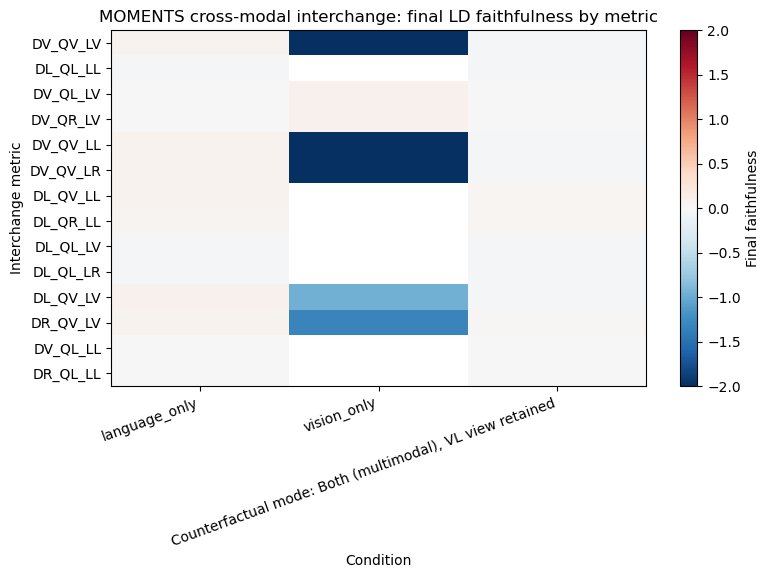

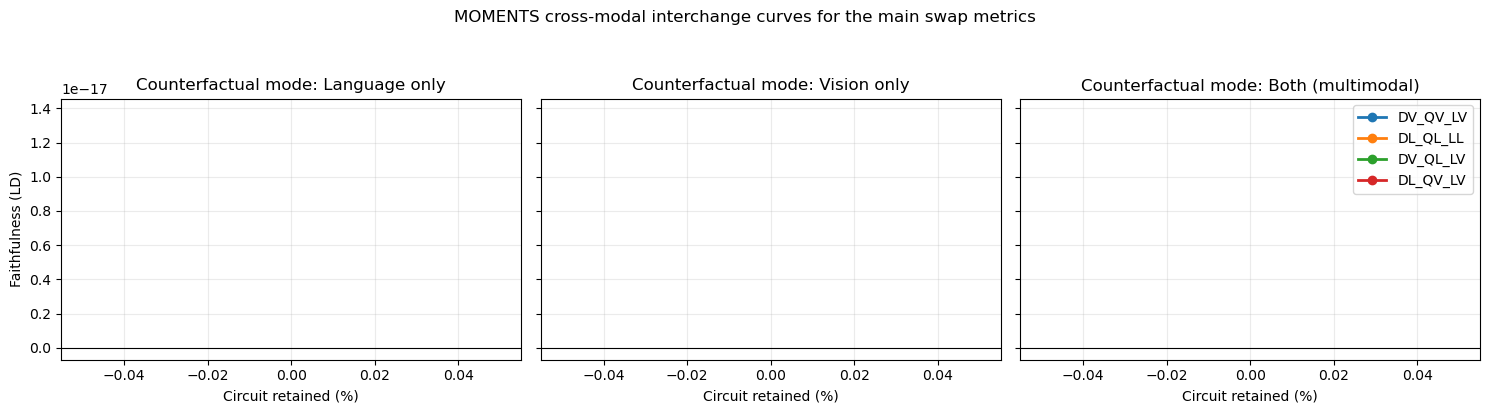

Saved cross-modal outputs to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results/cross_modality


In [29]:
CROSS_METRIC_ORDER = [
    'DV_QV_LV',
    'DL_QL_LL',
    'DV_QL_LV',
    'DV_QR_LV',
    'DV_QV_LL',
    'DV_QV_LR',
    'DL_QV_LL',
    'DL_QR_LL',
    'DL_QL_LV',
    'DL_QL_LR',
    'DL_QV_LV',
    'DR_QV_LV',
    'DV_QL_LL',
    'DR_QL_LL',
]

if cross_tables:
    summary_rows = []
    for mode, table in cross_tables.items():
        for metric, metric_table in table.groupby('metric'):
            metric_table = metric_table.sort_values('circuit_fraction')
            final_row = metric_table.iloc[-1]
            summary_rows.append({
                'mode': mode,
                'metric': metric,
                'final_percent': final_row['circuit_percent'],
                'final_faithfulness': final_row['faithfulness_LD'],
            })

    summary_df = pd.DataFrame(summary_rows)
    pivot = summary_df.pivot(index='metric', columns='mode', values='final_faithfulness')
    pivot = pivot.reindex([m for m in CROSS_METRIC_ORDER if m in pivot.index])
    pivot = pivot[[c for c in ['language_only', 'vision_only', 'both_multimodal'] if c in pivot.columns]]
    display(pivot)

    vmax = np.nanmax(np.abs(pivot.to_numpy(dtype=float))) if not pivot.empty else 1.0
    vmax = max(vmax, 1e-6)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(pivot))))
    im = ax.imshow(pivot.to_numpy(dtype=float), aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([RESULTS[name]['label'] if name in RESULTS else name for name in pivot.columns], rotation=20, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('MOMENTS cross-modal interchange: final LD faithfulness by metric')
    ax.set_xlabel('Condition')
    ax.set_ylabel('Interchange metric')
    fig.colorbar(im, ax=ax, label='Final faithfulness')
    fig.tight_layout()
    fig.savefig(CROSS_OUTPUT_DIR / 'cross_modal_final_heatmap.png', dpi=200, bbox_inches='tight')
    plt.show()

    key_metrics = ['DV_QV_LV', 'DL_QL_LL', 'DV_QL_LV', 'DL_QV_LV']
    available_modes = [mode for mode in ['language_only', 'vision_only', 'both_multimodal'] if mode in cross_tables]
    if available_modes:
        fig, axes = plt.subplots(1, len(available_modes), figsize=(5 * len(available_modes), 4), sharey=True)
        if len(available_modes) == 1:
            axes = [axes]
        for ax, mode in zip(axes, available_modes):
            table = cross_tables[mode]
            for metric in key_metrics:
                metric_table = table[table['metric'] == metric].sort_values('circuit_percent')
                if metric_table.empty:
                    continue
                ax.plot(metric_table['circuit_percent'], metric_table['faithfulness_LD'], marker='o', linewidth=2, label=metric)
            ax.axhline(0, color='black', linewidth=0.8)
            ax.set_title(MODE_TITLES.get(mode, mode))
            ax.set_xlabel('Circuit retained (%)')
            ax.grid(alpha=0.25)
        axes[0].set_ylabel('Faithfulness (LD)')
        axes[-1].legend(loc='best')
        fig.suptitle('MOMENTS cross-modal interchange curves for the main swap metrics', y=1.02)
        fig.tight_layout()
        fig.savefig(CROSS_OUTPUT_DIR / 'cross_modal_key_curves.png', dpi=200, bbox_inches='tight')
        plt.show()

    summary_df.to_csv(CROSS_OUTPUT_DIR / 'cross_modal_summary.csv', index=False)
    print('Saved cross-modal outputs to:', CROSS_OUTPUT_DIR.resolve())
else:
    print('Cross-modal result files are not available locally yet, so no plots were generated.')


## Table-5-style sweep

The fixed `0.01 / 0.03` intersection setting is useful as a compact comparison point, but it is not enough for a minimal-circuit claim. This section loads the saved MOMENTS sweep outputs for the `both` condition and visualizes how the retained-intersection scores change across the candidate circuit sizes.

The goal is to reproduce the paper-style logic: identify which size pairs have already been completed, inspect how the retained scores evolve, and use the sweep to support any threshold-style claim separately from the compact run.

,pair,l_percent,vl_percent,vl_head_iou,l_head_iou,vl_D_head_iou,l_D_head_iou,vl_mlp_iou,l_mlp_iou
0,l001_vl003,0.01,0.03,0.038078,0.102694,0.055475,0.001530,0.040516,0.104491
1,l002_vl005,0.02,0.05,0.050178,0.134717,0.072217,0.002846,0.051861,0.135258
2,l005_vl008,0.05,0.08,0.085546,0.226616,0.131691,0.005775,0.086967,0.223342
3,l010_vl010,0.10,0.10,0.136316,0.371476,0.197956,0.007618,0.138440,0.363710
4,l020_vl030,0.20,0.30,0.251223,0.397145,0.440487,0.116260,0.329955,0.413629
5,l030_vl050,0.30,0.50,0.351342,0.469933,0.599042,0.228130,0.439745,0.473264
6,l030_vl050,0.30,0.50,0.351342,0.469933,0.599042,0.228130,0.439745,0.473264


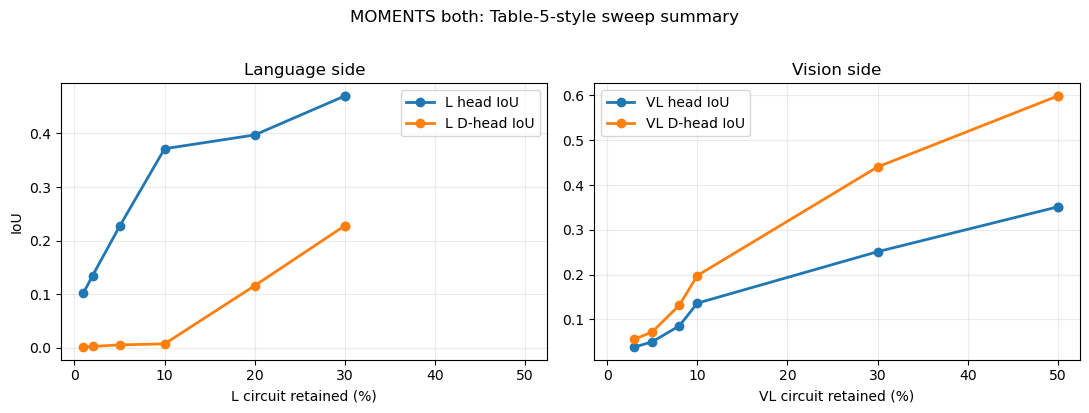

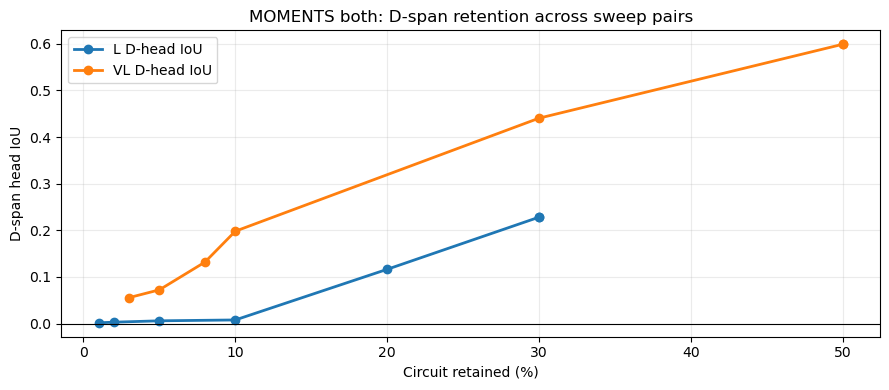

Saved Table-5 sweep outputs to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results


In [30]:
TABLE5_SWEEP_DIR = RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_nap_ig=5' / 'intersection' / 'table5_sweep'

def load_table5_payload(path):
    payload = torch.load(path, weights_only=True)
    if not isinstance(payload, dict):
        return None
    row = {'source_file': str(path), 'pair': path.parent.name}
    for key in ['l_percent', 'vl_percent', 'vl_head_iou', 'l_head_iou', 'vl_mlp_iou', 'l_mlp_iou', 'vl_D_head_iou', 'l_D_head_iou', 'vl_Q_head_iou', 'l_Q_head_iou', 'vl_G_head_iou', 'l_G_head_iou', 'vl_D_neurons_iou', 'l_D_neurons_iou', 'vl_Q_neurons_iou', 'l_Q_neurons_iou', 'vl_G_neurons_iou', 'l_G_neurons_iou', 'vl_head_baseline', 'l_head_baseline', 'vl_mlp_baseline', 'l_mlp_baseline', 'vl_D_head_baseline', 'l_D_head_baseline', 'vl_Q_head_baseline', 'l_Q_head_baseline', 'vl_G_head_baseline', 'l_G_head_baseline', 'vl_D_neurons_baseline', 'l_D_neurons_baseline', 'vl_Q_neurons_baseline', 'l_Q_neurons_baseline', 'vl_G_neurons_baseline', 'l_G_neurons_baseline']:
        if key in payload:
            value = payload[key]
            if torch.is_tensor(value):
                value = value.detach().float().cpu().item()
            row[key] = float(value)
    if 'empty_partitions' in payload:
        row['empty_partitions'] = payload['empty_partitions']
    return row

table5_rows = []
for path in sorted(TABLE5_SWEEP_DIR.glob('*/faithfulness_nodes_intersection_LD_*.pt')):
    row = load_table5_payload(path)
    if row is not None:
        table5_rows.append(row)

table5_df = pd.DataFrame(table5_rows)
if table5_df.empty:
    print(f'No Table-5 sweep outputs found yet in {TABLE5_SWEEP_DIR}')
else:
    if 'l_percent' in table5_df.columns and 'vl_percent' in table5_df.columns:
        table5_df = table5_df.sort_values(['l_percent', 'vl_percent']).reset_index(drop=True)
    display(table5_df[[c for c in ['pair', 'l_percent', 'vl_percent', 'vl_head_iou', 'l_head_iou', 'vl_D_head_iou', 'l_D_head_iou', 'vl_mlp_iou', 'l_mlp_iou'] if c in table5_df.columns]])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    axes[0].plot(table5_df['l_percent'] * 100.0, table5_df['l_head_iou'], marker='o', linewidth=2, label='L head IoU')
    axes[0].plot(table5_df['l_percent'] * 100.0, table5_df['l_D_head_iou'], marker='o', linewidth=2, label='L D-head IoU')
    axes[0].set_title('Language side')
    axes[0].set_xlabel('L circuit retained (%)')
    axes[0].set_ylabel('IoU')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(table5_df['vl_percent'] * 100.0, table5_df['vl_head_iou'], marker='o', linewidth=2, label='VL head IoU')
    axes[1].plot(table5_df['vl_percent'] * 100.0, table5_df['vl_D_head_iou'], marker='o', linewidth=2, label='VL D-head IoU')
    axes[1].set_title('Vision side')
    axes[1].set_xlabel('VL circuit retained (%)')
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.suptitle('MOMENTS both: Table-5-style sweep summary', y=1.02)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'table5_sweep_summary.png', dpi=200, bbox_inches='tight')
    plt.show()

    if 'vl_D_head_iou' in table5_df.columns and 'l_D_head_iou' in table5_df.columns:
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(table5_df['l_percent'] * 100.0, table5_df['l_D_head_iou'], marker='o', linewidth=2, label='L D-head IoU')
        ax.plot(table5_df['vl_percent'] * 100.0, table5_df['vl_D_head_iou'], marker='o', linewidth=2, label='VL D-head IoU')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Circuit retained (%)')
        ax.set_ylabel('D-span head IoU')
        ax.set_title('MOMENTS both: D-span retention across sweep pairs')
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / 'table5_sweep_dspan_iou.png', dpi=200, bbox_inches='tight')
        plt.show()

    table5_df.to_csv(OUTPUT_DIR / 'table5_sweep_summary.csv', index=False)
    print('Saved Table-5 sweep outputs to:', OUTPUT_DIR.resolve())


## Backpatching results

This section mirrors the backpatching block from the reference notebook. It is intentionally permissive: if a MOMENTS backpatching result file exists, it will summarize it; otherwise it will show the expected paths that still need to be generated.

For a paper-style reproduction, MOMENTS still needs a dedicated backpatching run for each condition you want to compare. The section below also builds appendix-style figures from the saved backpatching matrices and loop accuracies.

In [31]:
BACKPATCH_OUTPUT_DIR = OUTPUT_DIR / 'backpatching'
BACKPATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BACKPATCH_CANDIDATES = {
    'language_only': RESULTS_ROOT / 'qwen2-7b-vl-instruct_language_only_nap_ig=5' / 'backpatching',
    'vision_only': RESULTS_ROOT / 'qwen2-7b-vl-instruct_vision_only_nap_ig=5' / 'backpatching',
    'both_multimodal': RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_nap_ig=5' / 'backpatching',
}

def latest_backpatch_file(result_dir):
    files = sorted(result_dir.glob('backpatching_results*.pt'))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

backpatch_summaries = []
backpatch_payloads = {}
for mode, folder in BACKPATCH_CANDIDATES.items():
    latest = latest_backpatch_file(folder)
    if latest is None:
        print(f'No backpatching result file found yet for {mode}: {folder / "backpatching_results*.pt"}')
        continue
    payload = torch.load(latest, weights_only=False)
    if isinstance(payload, tuple) and len(payload) >= 3:
        backpatching_results, src_layer_range, dst_layer_range = payload[:3]
        clean_accs = backpatching_results.get('clean_accs', None)
        backpatch_payloads[mode] = {
            'source_file': str(latest),
            'results': backpatching_results,
            'src_layers': list(src_layer_range),
            'dst_layers': list(dst_layer_range),
            'clean_accs': clean_accs,
        }
        backpatch_summaries.append({
            'mode': mode,
            'source_file': str(latest),
            'src_layers': list(src_layer_range),
            'dst_layers': list(dst_layer_range),
            'clean_accs': clean_accs,
        })
    else:
        backpatch_summaries.append({
            'mode': mode,
            'source_file': str(latest),
            'src_layers': None,
            'dst_layers': None,
            'clean_accs': None,
        })
    print(f'{mode}: {latest}')

if backpatch_summaries:
    display(pd.DataFrame(backpatch_summaries))
else:
    print('No completed backpatching results are available locally yet.')

print('Expected backpatching job coverage for a full MOMENTS reproduction: language_only, vision_only, both_multimodal.')

language_only: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/backpatching/backpatching_results.pt
vision_only: data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/backpatching/backpatching_results.pt
both_multimodal: data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/backpatching/backpatching_results.pt


,mode,source_file,src_layers,dst_layers,clean_accs
0,language_only,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)"
1,vision_only,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)"
2,both_multimodal,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)"


Expected backpatching job coverage for a full MOMENTS reproduction: language_only, vision_only, both_multimodal.


## Backpatching appendix figures

These plots summarize the saved backpatching matrices for the MOMENTS conditions that have completed locally. They are appendix-style diagnostics, not model-scale benchmark summaries.

/scratch-local/76692/ipykernel_855702/3909357714.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


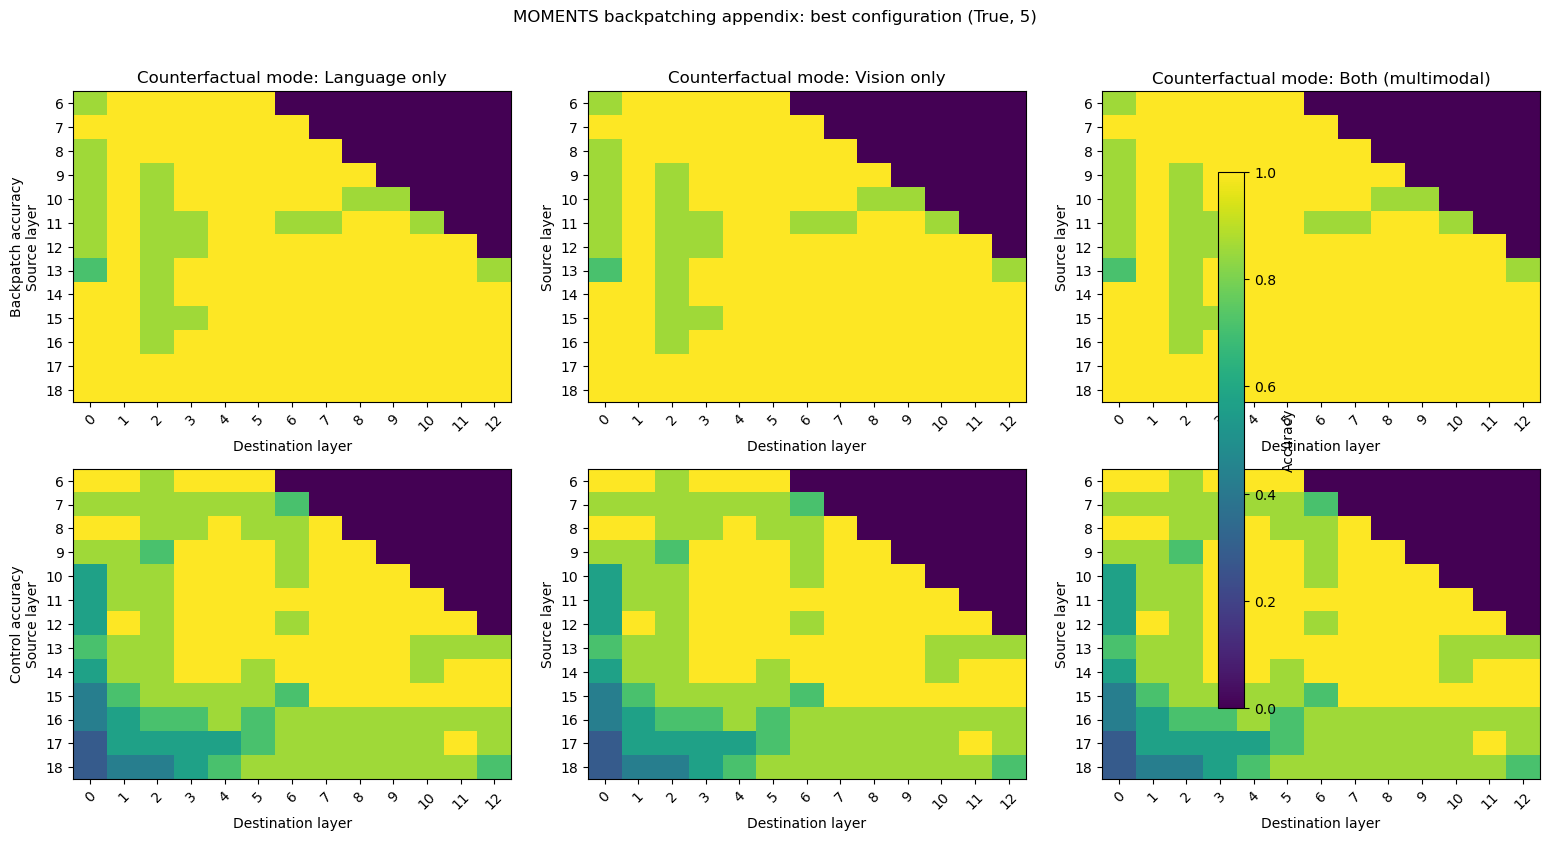

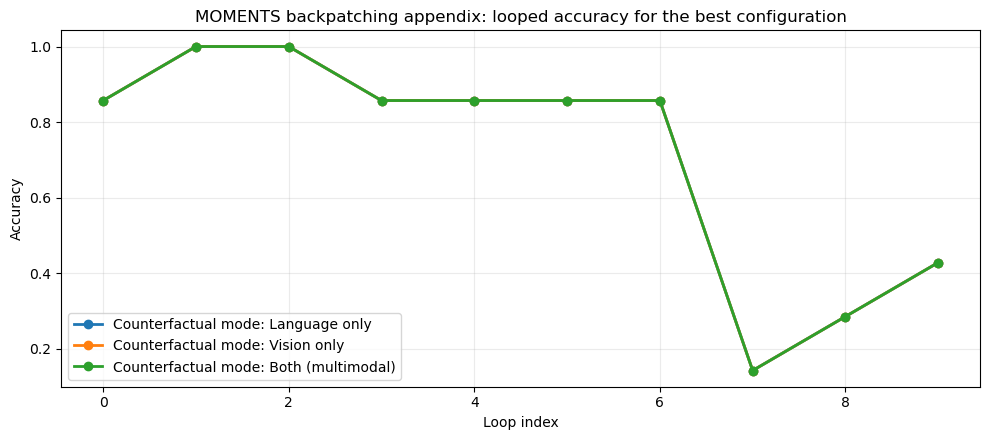

,mode,source_file,src_layers,dst_layers,clean_accs
0,language_only,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)"
1,vision_only,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)"
2,both_multimodal,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)"


Saved backpatching appendix figures to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results/backpatching


In [32]:
import numpy as np

BACKPATCH_KEY = (True, 5)
backpatch_modes = [mode for mode in ['language_only', 'vision_only', 'both_multimodal'] if mode in backpatch_payloads]
# backpatch_modes = [mode for mode in ['language_only', 'vision_only'] if mode in backpatch_payloads]

if backpatch_modes:
    # Heatmaps for the main backpatch matrix and the control matrix.
    fig, axes = plt.subplots(2, len(backpatch_modes), figsize=(5.2 * len(backpatch_modes), 8.2), sharex=False, sharey=False)
    if len(backpatch_modes) == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    heatmap_handles = []
    row_labels = ['Backpatch accuracy', 'Control accuracy']
    for col, mode in enumerate(backpatch_modes):
        payload = backpatch_payloads[mode]
        matrices = payload['results'].get(BACKPATCH_KEY)
        if matrices is None:
            continue
        src_layers = payload['src_layers']
        dst_layers = payload['dst_layers']
        for row in range(2):
            ax = axes[row, col]
            matrix = matrices[row].detach().float().cpu().numpy()
            im = ax.imshow(matrix, aspect='auto', cmap='viridis', vmin=0.0, vmax=1.0)
            heatmap_handles.append(im)
            if row == 0:
                ax.set_title(MODE_TITLES.get(mode, mode))
            ax.set_xlabel('Destination layer')
            ax.set_ylabel((row_labels[row] + '\nSource layer') if col == 0 else 'Source layer')
            ax.set_xticks(range(len(dst_layers)))
            ax.set_xticklabels(dst_layers, rotation=45)
            ax.set_yticks(range(len(src_layers)))
            ax.set_yticklabels(src_layers)
            ax.grid(False)
    if heatmap_handles:
        fig.colorbar(heatmap_handles[0], ax=axes.ravel().tolist(), shrink=0.85, label='Accuracy')
    fig.suptitle('MOMENTS backpatching appendix: best configuration (True, 5)', y=1.02)
    fig.tight_layout()
    fig.savefig(BACKPATCH_OUTPUT_DIR / 'backpatching_best_heatmaps.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Looped backpatching accuracies.
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for mode in backpatch_modes:
        payload = backpatch_payloads[mode]
        loop_points = []
        for idx in range(10):
            value = payload['results'].get((True, 5, idx))
            if value is not None:
                loop_points.append((idx, float(value)))
        if not loop_points:
            continue
        xs, ys = zip(*loop_points)
        ax.plot(xs, ys, marker='o', linewidth=2, label=MODE_TITLES.get(mode, mode))
    ax.set_xlabel('Loop index')
    ax.set_ylabel('Accuracy')
    ax.set_title('MOMENTS backpatching appendix: looped accuracy for the best configuration')
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(BACKPATCH_OUTPUT_DIR / 'backpatching_loop_accuracy.png', dpi=200, bbox_inches='tight')
    plt.show()

    backpatch_summary_df = pd.DataFrame(backpatch_summaries)
    display(backpatch_summary_df)
    backpatch_summary_df.to_csv(BACKPATCH_OUTPUT_DIR / 'backpatching_summary.csv', index=False)
    print('Saved backpatching appendix figures to:', BACKPATCH_OUTPUT_DIR.resolve())
else:
    print('No completed backpatching results are available locally yet.')

## New experiment variants: POS sigma and Qwen3

This section is intentionally additive: it keeps the original language/vision/both comparison above, then scans the newer result roots generated for POS-aware sigma perturbations and Qwen3. Missing files are reported instead of raising, so the same notebook can be rerun while Snellius jobs are still completing.


,variant,view,result_dir_exists,faithfulness_exists,scores_exists,all_checkpoints_completed,faithfulness_file,scores_file
0,qwen2_language_only,L,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/faithfulness_LD_l_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/node_scores/nap_ig_l_ig=5_metric=LD.pt
1,qwen2_language_only,VL,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/faithfulness_LD_vl_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/node_scores/nap_ig_vl_ig=5_metric=LD.pt
2,qwen2_vision_only,L,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/faithfulness_LD_l_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/node_scores/nap_ig_l_ig=5_metric=LD.pt
3,qwen2_vision_only,VL,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/faithfulness_LD_vl_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/node_scores/nap_ig_vl_ig=5_metric=LD.pt
4,qwen2_both_baseline,L,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/faithfulness_LD_l_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/node_scores/nap_ig_l_ig=5_metric=LD.pt
5,qwen2_both_baseline,VL,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/faithfulness_LD_vl_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/node_scores/nap_ig_vl_ig=5_metric=LD.pt
6,qwen2_both_POS_sigma0p12,L,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p12_nap_ig=5/faithfulness_LD_l_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p12_nap_ig=5/node_scores/nap_ig_l_ig=5_metric=LD.pt
7,qwen2_both_POS_sigma0p12,VL,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p12_nap_ig=5/faithfulness_LD_vl_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p12_nap_ig=5/node_scores/nap_ig_vl_ig=5_metric=LD.pt
8,qwen2_both_POS_sigma0p05,L,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/faithfulness_LD_l_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/node_scores/nap_ig_l_ig=5_metric=LD.pt
9,qwen2_both_POS_sigma0p05,VL,True,True,True,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/faithfulness_LD_vl_node_circuit.pt,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/node_scores/nap_ig_vl_ig=5_metric=LD.pt


,variant,view,circuit_fraction,circuit_percent,faithfulness_LD,completed,source_file
216,qwen2_both_POS_sigma0p05,L,0.000,0.000000,0.000000,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/faithfulness_LD_l_node_circuit.pt
217,qwen2_both_POS_sigma0p05,L,0.001,0.100000,0.001765,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/faithfulness_LD_l_node_circuit.pt
218,qwen2_both_POS_sigma0p05,L,0.005,0.500000,0.009810,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/faithfulness_LD_l_node_circuit.pt
219,qwen2_both_POS_sigma0p05,L,0.010,1.000000,0.005210,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/faithfulness_LD_l_node_circuit.pt
220,qwen2_both_POS_sigma0p05,L,0.020,2.000000,0.053171,True,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/faithfulness_LD_l_node_circuit.pt
...,...,...,...,...,...,...,...
427,qwen3_both_baseline,VL,0.200,20.000000,-0.017558,True,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/faithfulness_LD_vl_node_circuit.pt
428,qwen3_both_baseline,VL,0.300,30.000001,0.230623,True,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/faithfulness_LD_vl_node_circuit.pt
429,qwen3_both_baseline,VL,0.500,50.000000,0.611493,True,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/faithfulness_LD_vl_node_circuit.pt
430,qwen3_both_baseline,VL,0.700,69.999999,0.729879,True,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/faithfulness_LD_vl_node_circuit.pt


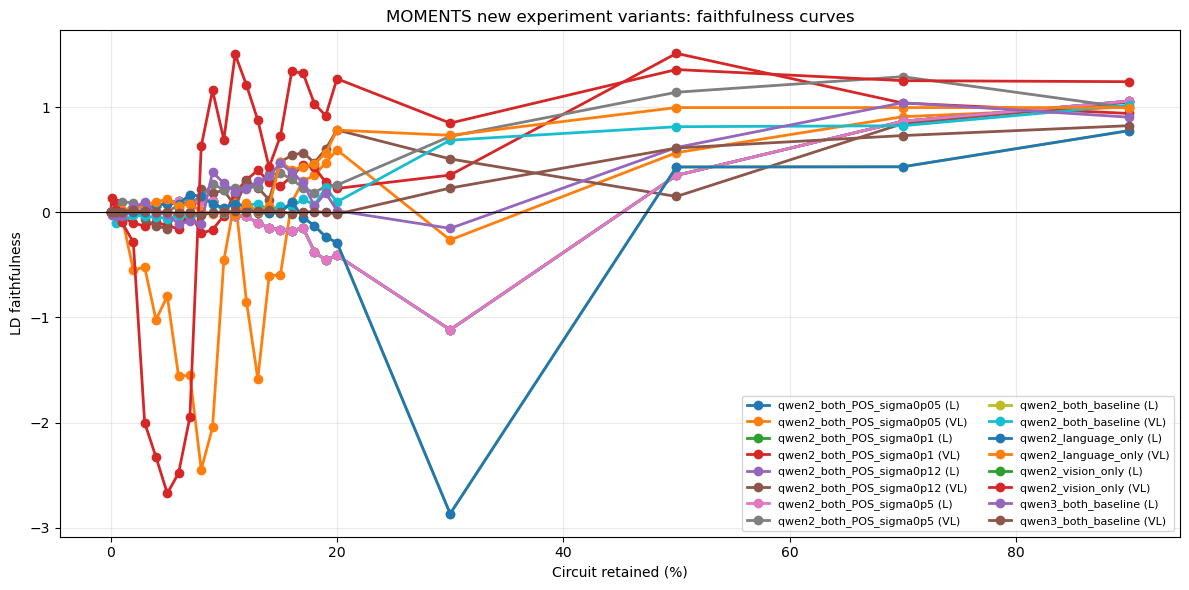

Saved variant availability and faithfulness outputs to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results/new_experiment_variants


In [33]:
from pathlib import Path
import math
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if 'REPO_ROOT' not in globals():
    if Path('data/moments_goal/results').exists():
        REPO_ROOT = Path('.')
    elif Path('reproducing_code/vlm-circuits-analysis/data/moments_goal/results').exists():
        REPO_ROOT = Path('reproducing_code/vlm-circuits-analysis')
    else:
        REPO_ROOT = Path('.')
if 'RESULTS_ROOT' not in globals():
    RESULTS_ROOT = REPO_ROOT / 'data/moments_goal/results'
if 'OUTPUT_DIR' not in globals():
    OUTPUT_DIR = REPO_ROOT / 'figures/moments_language_vision_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VARIANT_OUTPUT_DIR = OUTPUT_DIR / 'new_experiment_variants'
VARIANT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_VARIANTS = {
    'qwen2_language_only': RESULTS_ROOT / 'qwen2-7b-vl-instruct_language_only_nap_ig=5',
    'qwen2_vision_only': RESULTS_ROOT / 'qwen2-7b-vl-instruct_vision_only_nap_ig=5',
    'qwen2_both_baseline': RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_nap_ig=5',
    'qwen2_both_POS_sigma0p12': RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_POS_sigma0p12_nap_ig=5',
    'qwen2_both_POS_sigma0p05': RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5',
    'qwen2_both_POS_sigma0p1': RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_POS_sigma0p1_nap_ig=5',
    'qwen2_both_POS_sigma0p5': RESULTS_ROOT / 'qwen2-7b-vl-instruct_both_POS_sigma0p5_nap_ig=5',
    'qwen3_both_baseline': RESULTS_ROOT / 'qwen3-8b-vl-instruct_both_nap_ig=5',
}

VIEW_FILES = {
    'L': {
        'faithfulness': 'faithfulness_LD_l_node_circuit.pt',
        'scores': 'node_scores/nap_ig_l_ig=5_metric=LD.pt',
    },
    'VL': {
        'faithfulness': 'faithfulness_LD_vl_node_circuit.pt',
        'scores': 'node_scores/nap_ig_vl_ig=5_metric=LD.pt',
    },
}

def tensor_diag_or_flat(value):
    if torch.is_tensor(value):
        value = value.detach().float().cpu()
        if value.ndim == 0:
            return [float(value.item())]
        if value.ndim == 1:
            return [float(x) for x in value.tolist()]
        return [float(x) for x in value.diag().tolist()]
    return [float(x) for x in list(value)]

def load_faithfulness_table(variant, view, path):
    percentages, values, completed = torch.load(path, weights_only=True)
    percentages = tensor_diag_or_flat(percentages)
    values = tensor_diag_or_flat(values)
    completed = [bool(x) for x in tensor_diag_or_flat(completed)]
    return pd.DataFrame({
        'variant': variant,
        'view': view,
        'circuit_fraction': percentages,
        'circuit_percent': [x * 100.0 for x in percentages],
        'faithfulness_LD': values,
        'completed': completed,
        'source_file': str(path),
    })

availability_rows = []
faithfulness_tables = []
for variant, result_dir in EXPERIMENT_VARIANTS.items():
    for view, files in VIEW_FILES.items():
        faithfulness_path = result_dir / files['faithfulness']
        scores_path = result_dir / files['scores']
        row = {
            'variant': variant,
            'view': view,
            'result_dir_exists': result_dir.exists(),
            'faithfulness_exists': faithfulness_path.exists(),
            'scores_exists': scores_path.exists(),
            'all_checkpoints_completed': False,
            'faithfulness_file': str(faithfulness_path),
            'scores_file': str(scores_path),
        }
        if faithfulness_path.exists():
            try:
                table = load_faithfulness_table(variant, view, faithfulness_path)
                row['all_checkpoints_completed'] = bool(table['completed'].all())
                faithfulness_tables.append(table)
            except Exception as exc:
                row['load_error'] = repr(exc)
        availability_rows.append(row)

availability_df = pd.DataFrame(availability_rows)
display(availability_df)
availability_df.to_csv(VARIANT_OUTPUT_DIR / 'variant_availability.csv', index=False)

if faithfulness_tables:
    variant_faithfulness_df = pd.concat(faithfulness_tables, ignore_index=True)
    display(variant_faithfulness_df.sort_values(['variant', 'view', 'circuit_fraction']))
    variant_faithfulness_df.to_csv(VARIANT_OUTPUT_DIR / 'variant_faithfulness_curves.csv', index=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    for (variant, view), table in variant_faithfulness_df.groupby(['variant', 'view']):
        table = table.sort_values('circuit_fraction')
        linestyle = '-' if table['completed'].all() else '--'
        ax.plot(
            table['circuit_percent'],
            table['faithfulness_LD'],
            marker='o',
            linewidth=2,
            linestyle=linestyle,
            label=f'{variant} ({view})',
        )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Circuit retained (%)')
    ax.set_ylabel('LD faithfulness')
    ax.set_title('MOMENTS new experiment variants: faithfulness curves')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(VARIANT_OUTPUT_DIR / 'variant_faithfulness_curves.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('No variant faithfulness files were found yet.')

print('Saved variant availability and faithfulness outputs to:', VARIANT_OUTPUT_DIR.resolve())


,variant,l_percent,vl_percent,l_head_iou,vl_head_iou,l_mlp_iou,vl_mlp_iou,l_D_head_iou,vl_D_head_iou,source_file
0,qwen2_language_only,0.01,0.03,0.148073,0.036923,0.138545,0.033991,0.000000,0.000000,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_26056296.pt
1,qwen2_vision_only,0.01,0.03,0.015797,0.001278,0.005357,0.009171,0.001643,0.016611,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_25683887.pt
2,qwen2_vision_only,0.01,0.03,0.015797,0.001278,0.005357,0.009171,0.001643,0.016611,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_26056297.pt
3,qwen2_both_baseline,0.01,0.03,0.102694,0.038078,0.104491,0.040516,0.001530,0.055475,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_25682988.pt
4,qwen2_both_POS_sigma0p12,0.01,0.03,0.099739,0.037920,0.104254,0.039953,0.001466,0.052971,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p12_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_26486594.pt
5,qwen2_both_POS_sigma0p05,0.01,0.03,0.106153,0.037868,0.105882,0.039327,0.001275,0.037604,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_26522148.pt
6,qwen2_both_POS_sigma0p1,0.01,0.03,0.095696,0.038709,0.097939,0.041282,0.002358,0.053924,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p1_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_26522144.pt
7,qwen2_both_POS_sigma0p5,0.01,0.03,0.060144,0.041136,0.068863,0.045848,0.006285,0.040417,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p5_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_26522147.pt
8,qwen3_both_baseline,0.01,0.03,0.014375,0.034766,0.021838,0.102332,0.034790,0.014379,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/intersection/faithfulness_nodes_intersection_LD_26488207.pt


,variant,pair,l_percent,vl_percent,l_D_head_iou,vl_D_head_iou,l_head_iou,vl_head_iou,l_mlp_iou,vl_mlp_iou,source_file
0,qwen2_both_POS_sigma0p05,l001_vl003,0.01,0.03,0.001275,0.037604,0.106153,0.037868,0.105882,0.039327,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l001_vl003/faithfulness_nodes_inter...
1,qwen2_both_POS_sigma0p05,l002_vl005,0.02,0.05,0.002607,0.079688,0.142438,0.049978,0.136849,0.050251,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l002_vl005/faithfulness_nodes_inter...
2,qwen2_both_POS_sigma0p05,l005_vl008,0.05,0.08,0.004925,0.132806,0.236892,0.084657,0.224920,0.084534,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l005_vl008/faithfulness_nodes_inter...
3,qwen2_both_POS_sigma0p05,l010_vl010,0.10,0.10,0.006576,0.187346,0.388445,0.135040,0.365001,0.135439,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l010_vl010/faithfulness_nodes_inter...
4,qwen2_both_POS_sigma0p05,l020_vl030,0.20,0.30,0.111807,0.436507,0.394731,0.246061,0.409544,0.322039,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l020_vl030/faithfulness_nodes_inter...
5,qwen2_both_POS_sigma0p05,l030_vl050,0.30,0.50,0.225177,0.602038,0.468212,0.348773,0.471096,0.432282,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l030_vl050/faithfulness_nodes_inter...
6,qwen2_both_POS_sigma0p05,l050_vl070,0.50,0.70,0.345719,0.686027,0.595470,0.505002,0.609939,0.580864,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l050_vl070/faithfulness_nodes_inter...
7,qwen2_both_POS_sigma0p05,l070_vl090,0.70,0.90,0.522128,0.797804,0.674289,0.689526,0.686457,0.687627,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/intersection/table5_sweep/l070_vl090/faithfulness_nodes_inter...
8,qwen2_both_POS_sigma0p1,l001_vl003,0.01,0.03,0.002358,0.053924,0.095696,0.038709,0.097939,0.041282,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p1_nap_ig=5/intersection/table5_sweep/l001_vl003/faithfulness_nodes_inters...
9,qwen2_both_POS_sigma0p1,l002_vl005,0.02,0.05,0.004329,0.071855,0.125637,0.051350,0.127458,0.053018,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p1_nap_ig=5/intersection/table5_sweep/l002_vl005/faithfulness_nodes_inters...


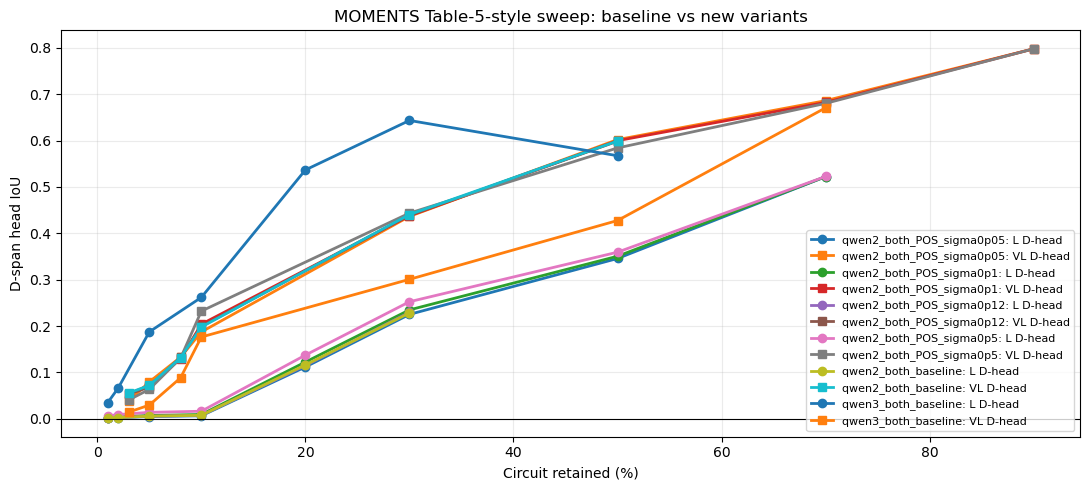

,variant,pair,l_percent,vl_percent,l_D_head_iou,vl_D_head_iou,l_mlp_iou,vl_mlp_iou,source_file
0,qwen2_both_baseline,l01_vl01,0.01,0.01,0.000383,0.026256,0.207307,0.034428,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl01/faithfulness_nodes_intersection_LD_26456309.pt
1,qwen2_both_baseline,l01_vl02,0.01,0.02,0.000702,0.029878,0.139953,0.039364,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl02/faithfulness_nodes_intersection_LD_26456309.pt
2,qwen2_both_baseline,l01_vl03,0.01,0.03,0.001530,0.055475,0.104491,0.040516,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl03/faithfulness_nodes_intersection_LD_26456309.pt
3,qwen2_both_baseline,l01_vl04,0.01,0.04,0.002485,0.051951,0.083095,0.040853,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl04/faithfulness_nodes_intersection_LD_26456309.pt
4,qwen2_both_baseline,l01_vl05,0.01,0.05,0.003566,0.046989,0.068829,0.041110,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl05/faithfulness_nodes_intersection_LD_26456309.pt
5,qwen2_both_baseline,l01_vl06,0.01,0.06,0.005025,0.041727,0.058723,0.041609,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl06/faithfulness_nodes_intersection_LD_26456309.pt
6,qwen2_both_baseline,l01_vl07,0.01,0.07,0.007116,0.046173,0.051230,0.042510,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl07/faithfulness_nodes_intersection_LD_26456309.pt
7,qwen2_both_baseline,l01_vl08,0.01,0.08,0.009452,0.043608,0.045489,0.043887,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl08/faithfulness_nodes_intersection_LD_26456309.pt
8,qwen2_both_baseline,l01_vl09,0.01,0.09,0.012154,0.040147,0.041130,0.045824,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl09/faithfulness_nodes_intersection_LD_26456309.pt
9,qwen2_both_baseline,l01_vl10,0.01,0.10,0.015088,0.037751,0.037809,0.048330,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/intersection/grid_1_20/l01_vl10/faithfulness_nodes_intersection_LD_26456309.pt


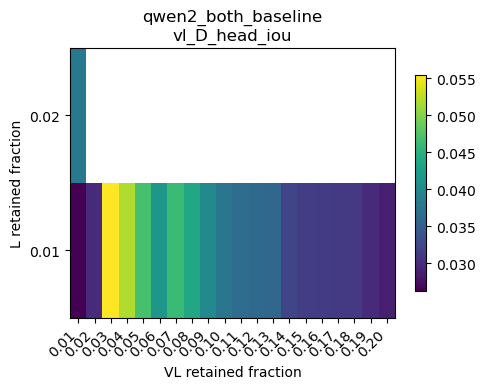

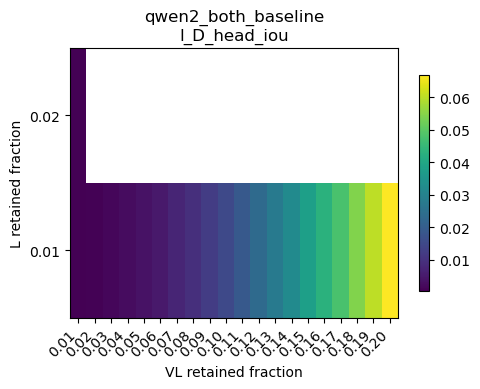

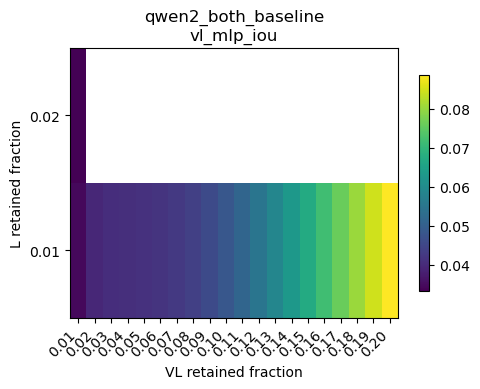

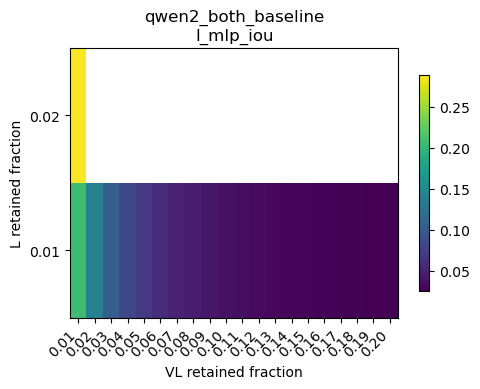

,variant,metric,circuit_fraction,circuit_percent,faithfulness_LD,completed,has_percentage_axis,source_file
57,qwen2_both_POS_sigma0p05,DL_QL_LL,NaN,NaN,0.005210,True,False,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26522...
65,qwen2_both_POS_sigma0p05,DL_QL_LR,NaN,NaN,0.005210,True,False,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26522...
64,qwen2_both_POS_sigma0p05,DL_QL_LV,NaN,NaN,0.005210,True,False,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26522...
63,qwen2_both_POS_sigma0p05,DL_QR_LL,NaN,NaN,0.079850,True,False,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26522...
62,qwen2_both_POS_sigma0p05,DL_QV_LL,NaN,NaN,0.078663,True,False,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26522...
...,...,...,...,...,...,...,...,...
100,qwen3_both_baseline,DV_QL_LV,NaN,NaN,0.012652,True,False,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26488219.pt
101,qwen3_both_baseline,DV_QR_LV,NaN,NaN,0.010954,True,False,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26488219.pt
102,qwen3_both_baseline,DV_QV_LL,NaN,NaN,0.008663,True,False,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26488219.pt
103,qwen3_both_baseline,DV_QV_LR,NaN,NaN,0.008663,True,False,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/cross_modality/faithfulness_nodes_cross_interchanges_LD_26488219.pt


,variant,source_file,src_layers,dst_layers,clean_accs,available_keys
0,qwen2_language_only,data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."
1,qwen2_vision_only,data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."
2,qwen2_both_baseline,data/moments_goal/results/qwen2-7b-vl-instruct_both_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."
3,qwen2_both_POS_sigma0p12,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p12_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."
4,qwen2_both_POS_sigma0p05,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p05_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."
5,qwen2_both_POS_sigma0p1,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p1_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."
6,qwen2_both_POS_sigma0p5,data/moments_goal/results/qwen2-7b-vl-instruct_both_POS_sigma0p5_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.8571428656578064, 1.0)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."
7,qwen3_both_baseline,data/moments_goal/results/qwen3-8b-vl-instruct_both_nap_ig=5/backpatching/backpatching_results.pt,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","(0.7142857313156128, 0.5714285969734192)","[(True, 1), (True, 3), (True, 5), (True, 5, 0), (True, 5, 1), (True, 5, 2), (True, 5, 3), (True, 5, 4), (True, 5, 5), (True, 5, 6), (Tru..."


Saved new experiment variant summaries to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results/new_experiment_variants


In [34]:
import numpy as np

SCALAR_KEYS = [
    'l_percent', 'vl_percent',
    'l_D_heads_count', 'vl_D_heads_count', 'l_Q_heads_count', 'vl_Q_heads_count', 'l_G_heads_count', 'vl_G_heads_count',
    'l_D_neurons_count', 'vl_D_neurons_count', 'l_Q_neurons_count', 'vl_Q_neurons_count', 'l_G_neurons_count', 'vl_G_neurons_count',
    'vl_head_iou', 'l_head_iou', 'vl_mlp_iou', 'l_mlp_iou',
    'vl_head_baseline', 'vl_mlp_baseline', 'l_head_baseline', 'l_mlp_baseline',
    'vl_D_head_iou', 'l_D_head_iou', 'vl_Q_head_iou', 'l_Q_head_iou', 'vl_G_head_iou', 'l_G_head_iou',
    'vl_D_neurons_iou', 'l_D_neurons_iou', 'vl_Q_neurons_iou', 'l_Q_neurons_iou', 'vl_G_neurons_iou', 'l_G_neurons_iou',
    'vl_D_head_baseline', 'l_D_head_baseline', 'vl_Q_head_baseline', 'l_Q_head_baseline', 'vl_G_head_baseline', 'l_G_head_baseline',
    'vl_D_neurons_baseline', 'l_D_neurons_baseline', 'vl_Q_neurons_baseline', 'l_Q_neurons_baseline', 'vl_G_neurons_baseline', 'l_G_neurons_baseline',
    'vl_D_head_iou_no_pos', 'l_D_head_iou_no_pos', 'vl_D_neurons_iou_no_pos', 'l_D_neurons_iou_no_pos',
    'vl_D_head_baseline_no_pos', 'l_D_head_baseline_no_pos', 'vl_D_neurons_baseline_no_pos', 'l_D_neurons_baseline_no_pos',
]

def scalarize(value):
    if torch.is_tensor(value):
        value = value.detach().float().cpu()
        if value.numel() == 1:
            return float(value.item())
        return float(value.flatten()[0].item())
    if isinstance(value, (int, float, bool)):
        return float(value)
    return value

def load_scalar_payload(path, extra=None):
    payload = torch.load(path, weights_only=True)
    if not isinstance(payload, dict):
        return None
    row = {'source_file': str(path)}
    if extra:
        row.update(extra)
    for key in SCALAR_KEYS:
        if key in payload:
            row[key] = scalarize(payload[key])
    if 'empty_partitions' in payload:
        row['empty_partitions'] = str(payload['empty_partitions'])
    return row

def latest_file(folder, pattern):
    files = list(folder.glob(pattern))
    return max(files, key=lambda p: p.stat().st_mtime) if files else None

# Fixed intersection summaries.
intersection_rows = []
for variant, result_dir in EXPERIMENT_VARIANTS.items():
    for path in sorted((result_dir / 'intersection').glob('faithfulness_nodes_intersection_LD_*.pt')):
        row = load_scalar_payload(path, {'variant': variant, 'analysis': 'fixed_intersection'})
        if row is not None:
            intersection_rows.append(row)

intersection_df = pd.DataFrame(intersection_rows)
if intersection_df.empty:
    print('No fixed intersection outputs found for the configured variants yet.')
else:
    display(intersection_df[[c for c in ['variant', 'l_percent', 'vl_percent', 'l_head_iou', 'vl_head_iou', 'l_mlp_iou', 'vl_mlp_iou', 'l_D_head_iou', 'vl_D_head_iou', 'source_file'] if c in intersection_df.columns]])
    intersection_df.to_csv(VARIANT_OUTPUT_DIR / 'variant_fixed_intersection_summary.csv', index=False)

# Table-5-style retained-fraction sweep summaries, including the POS/sigma root when present.
table5_rows = []
for variant, result_dir in EXPERIMENT_VARIANTS.items():
    sweep_dir = result_dir / 'intersection' / 'table5_sweep'
    for path in sorted(sweep_dir.glob('*/faithfulness_nodes_intersection_LD_*.pt')):
        row = load_scalar_payload(path, {'variant': variant, 'pair': path.parent.name, 'analysis': 'table5_sweep'})
        if row is not None:
            table5_rows.append(row)

table5_variant_df = pd.DataFrame(table5_rows)
if table5_variant_df.empty:
    print('No Table-5 sweep outputs found for the configured variants yet.')
else:
    table5_variant_df = table5_variant_df.sort_values(['variant', 'l_percent', 'vl_percent', 'source_file']).reset_index(drop=True)
    display(table5_variant_df[[c for c in ['variant', 'pair', 'l_percent', 'vl_percent', 'l_D_head_iou', 'vl_D_head_iou', 'l_head_iou', 'vl_head_iou', 'l_mlp_iou', 'vl_mlp_iou', 'source_file'] if c in table5_variant_df.columns]])
    table5_variant_df.to_csv(VARIANT_OUTPUT_DIR / 'variant_table5_sweep_summary.csv', index=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    for variant, table in table5_variant_df.groupby('variant'):
        table = table.sort_values(['l_percent', 'vl_percent'])
        if 'l_D_head_iou' in table.columns:
            ax.plot(table['l_percent'] * 100.0, table['l_D_head_iou'], marker='o', linewidth=2, label=f'{variant}: L D-head')
        if 'vl_D_head_iou' in table.columns:
            ax.plot(table['vl_percent'] * 100.0, table['vl_D_head_iou'], marker='s', linewidth=2, label=f'{variant}: VL D-head')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Circuit retained (%)')
    ax.set_ylabel('D-span head IoU')
    ax.set_title('MOMENTS Table-5-style sweep: baseline vs new variants')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(VARIANT_OUTPUT_DIR / 'variant_table5_sweep_dspan_iou.png', dpi=200, bbox_inches='tight')
    plt.show()

# Full grid_1_20 heatmaps. This catches partial grids such as interrupted jobs.
grid_rows = []
for variant, result_dir in EXPERIMENT_VARIANTS.items():
    grid_dir = result_dir / 'intersection' / 'grid_1_20'
    for path in sorted(grid_dir.glob('*/faithfulness_nodes_intersection_LD_*.pt')):
        row = load_scalar_payload(path, {'variant': variant, 'pair': path.parent.name, 'analysis': 'grid_1_20'})
        if row is not None:
            grid_rows.append(row)

grid_df = pd.DataFrame(grid_rows)
if grid_df.empty:
    print('No grid_1_20 outputs found for the configured variants yet.')
else:
    grid_df = grid_df.sort_values(['variant', 'l_percent', 'vl_percent', 'source_file']).reset_index(drop=True)
    display(grid_df[[c for c in ['variant', 'pair', 'l_percent', 'vl_percent', 'l_D_head_iou', 'vl_D_head_iou', 'l_mlp_iou', 'vl_mlp_iou', 'source_file'] if c in grid_df.columns]])
    grid_df.to_csv(VARIANT_OUTPUT_DIR / 'variant_grid_1_20_summary.csv', index=False)

    for metric in [m for m in ['vl_D_head_iou', 'l_D_head_iou', 'vl_mlp_iou', 'l_mlp_iou'] if m in grid_df.columns]:
        variants = list(grid_df['variant'].drop_duplicates())
        fig, axes = plt.subplots(1, len(variants), figsize=(5 * len(variants), 4), squeeze=False)
        for ax, variant in zip(axes.ravel(), variants):
            table = grid_df[grid_df['variant'] == variant]
            pivot = table.pivot_table(index='l_percent', columns='vl_percent', values=metric, aggfunc='last').sort_index().sort_index(axis=1)
            im = ax.imshow(pivot.values, aspect='auto', origin='lower')
            ax.set_title(f'{variant}\n{metric}')
            ax.set_xlabel('VL retained fraction')
            ax.set_ylabel('L retained fraction')
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f'{x:.2f}' for x in pivot.columns], rotation=45, ha='right')
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([f'{x:.2f}' for x in pivot.index])
            fig.colorbar(im, ax=ax, shrink=0.8)
        fig.tight_layout()
        fig.savefig(VARIANT_OUTPUT_DIR / f'variant_grid_1_20_{metric}.png', dpi=200, bbox_inches='tight')
        plt.show()

# Cross-modal summaries.
def cross_values_to_rows(variant, payload_path):
    payload = torch.load(payload_path, weights_only=True)
    rows = []
    if not isinstance(payload, dict):
        return rows
    for metric, value in payload.items():
        has_percentage_axis = True
        if isinstance(value, dict) and {'percentages', 'values'}.issubset(value):
            percentages = tensor_diag_or_flat(value['percentages'])
            values = tensor_diag_or_flat(value['values'])
            completed = tensor_diag_or_flat(value.get('completed', [True] * len(values)))
        elif isinstance(value, (tuple, list)) and len(value) >= 2:
            percentages = tensor_diag_or_flat(value[0])
            values = tensor_diag_or_flat(value[1])
            completed = tensor_diag_or_flat(value[2]) if len(value) > 2 else [True] * len(values)
        elif torch.is_tensor(value):
            values = tensor_diag_or_flat(value)
            completed = [True] * len(values)
            percentages = [float('nan')] if len(values) == 1 else list(range(len(values)))
            has_percentage_axis = len(values) > 1
        else:
            continue
        for pct, faith, done in zip(percentages, values, completed):
            rows.append({
                'variant': variant,
                'metric': str(metric),
                'circuit_fraction': float(pct) if pct == pct else float('nan'),
                'circuit_percent': float(pct) * 100.0 if pct == pct else float('nan'),
                'faithfulness_LD': float(faith),
                'completed': bool(done),
                'has_percentage_axis': has_percentage_axis,
                'source_file': str(payload_path),
            })
    return rows

cross_rows = []
for variant, result_dir in EXPERIMENT_VARIANTS.items():
    latest = latest_file(result_dir / 'cross_modality', 'faithfulness_nodes_cross_interchanges_LD_*.pt')
    if latest is not None:
        cross_rows.extend(cross_values_to_rows(variant, latest))

cross_variant_df = pd.DataFrame(cross_rows)
if cross_variant_df.empty:
    print('No cross-modal interchange outputs found for the configured variants yet.')
else:
    display(cross_variant_df.sort_values(['variant', 'metric', 'circuit_fraction']))
    cross_variant_df.to_csv(VARIANT_OUTPUT_DIR / 'variant_cross_modality_summary.csv', index=False)

# Backpatching availability and summaries.
backpatch_rows = []
for variant, result_dir in EXPERIMENT_VARIANTS.items():
    latest = latest_file(result_dir / 'backpatching', 'backpatching_results*.pt')
    if latest is None:
        continue
    row = {'variant': variant, 'source_file': str(latest)}
    try:
        payload = torch.load(latest, weights_only=False)
        if isinstance(payload, tuple) and len(payload) >= 3:
            results, src_layers, dst_layers = payload[:3]
            row['src_layers'] = list(src_layers)
            row['dst_layers'] = list(dst_layers)
            row['clean_accs'] = results.get('clean_accs') if isinstance(results, dict) else None
            row['available_keys'] = sorted([str(k) for k in results.keys()]) if isinstance(results, dict) else None
    except Exception as exc:
        row['load_error'] = repr(exc)
    backpatch_rows.append(row)

backpatch_variant_df = pd.DataFrame(backpatch_rows)
if backpatch_variant_df.empty:
    print('No backpatching outputs found for the configured variants yet.')
else:
    display(backpatch_variant_df)
    backpatch_variant_df.to_csv(VARIANT_OUTPUT_DIR / 'variant_backpatching_summary.csv', index=False)

print('Saved new experiment variant summaries to:', VARIANT_OUTPUT_DIR.resolve())


## Behavioral Accuracy Summaries

This section visualizes the clean behavioral evaluation artifacts used to contextualize the circuit results. It reads the saved Qwen2 goal/no-goal CSV, the Qwen2 event-type CSV, and the Qwen3 goal/no-goal CSV when they are available, then writes summary tables and figures to `figures/moments_language_vision_results/behavior/`.

,model,task,group,target,n,correct,accuracy
0,Qwen2-7B-VL,goal_clean_yes_no,overall,all,146,126,0.863014
1,Qwen2-7B-VL,goal_clean_yes_no,target,no,96,86,0.895833
2,Qwen2-7B-VL,goal_clean_yes_no,target,yes,50,40,0.800000
3,Qwen3-8B-VL,goal_clean_yes_no,overall,all,146,81,0.554795
4,Qwen3-8B-VL,goal_clean_yes_no,target,no,96,63,0.656250
5,Qwen3-8B-VL,goal_clean_yes_no,target,yes,50,18,0.360000


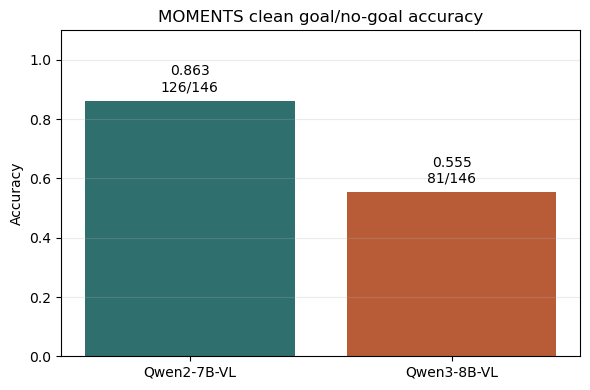

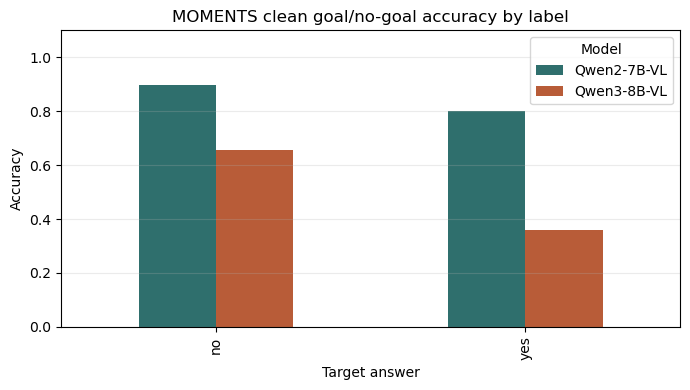

,model,task,group,target,n,correct,accuracy
0,Qwen2-7B-VL,event_type_clean,overall,all,146,78,0.534247
1,Qwen2-7B-VL,event_type_clean,target,CORNER/THROW-IN,47,25,0.531915
2,Qwen2-7B-VL,event_type_clean,target,GOAL,50,41,0.820000
3,Qwen2-7B-VL,event_type_clean,target,SHOT-ON-TARGET,49,12,0.244898


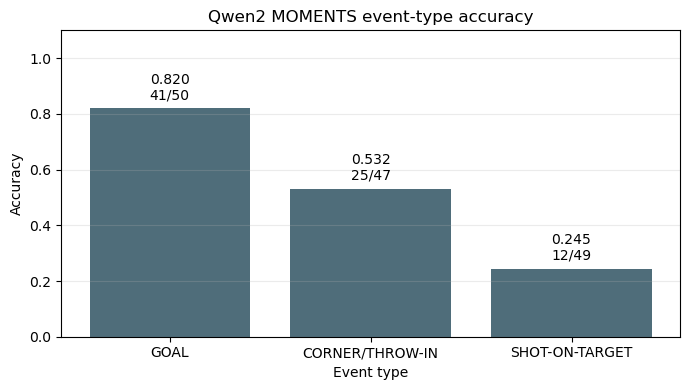

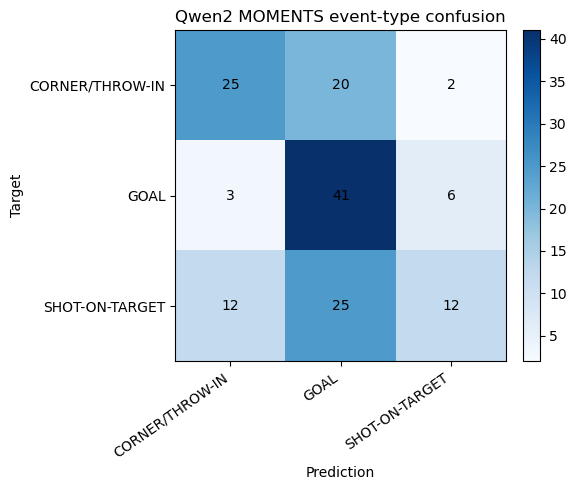

Saved behavior summaries and figures to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results/behavior


In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if 'REPO_ROOT' not in globals():
    if Path('data/moments_goal/results').exists():
        REPO_ROOT = Path('.')
    elif Path('reproducing_code/vlm-circuits-analysis/data/moments_goal/results').exists():
        REPO_ROOT = Path('reproducing_code/vlm-circuits-analysis')
    else:
        REPO_ROOT = Path('.')
if 'RESULTS_ROOT' not in globals():
    RESULTS_ROOT = REPO_ROOT / 'data/moments_goal/results'
if 'OUTPUT_DIR' not in globals():
    OUTPUT_DIR = REPO_ROOT / 'figures/moments_language_vision_results'

BEHAVIOR_OUTPUT_DIR = OUTPUT_DIR / 'behavior'
BEHAVIOR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEHAVIOR_FILES = {
    'qwen2_goal_clean': RESULTS_ROOT / 'qwen2_behavioral_evaluation/behavior_clean.csv',
    'qwen2_event_type_clean': RESULTS_ROOT / 'qwen2_behavioral_evaluation/behavior_event_type_clean.csv',
    'qwen3_goal_clean': RESULTS_ROOT / 'qwen3-vl-8b-instruct/behavior_clean_both.csv',
}

def load_behavior_csv(name, path):
    if not path.exists():
        print(f'Missing behavior CSV for {name}: {path}')
        return None
    table = pd.read_csv(path)
    table['source_file'] = str(path)
    return table

def summarize_classification(table, model, task, target_col, pred_col, correct_col):
    rows = []
    correct = table[correct_col].astype(bool)
    rows.append({
        'model': model,
        'task': task,
        'group': 'overall',
        'target': 'all',
        'n': int(len(table)),
        'correct': int(correct.sum()),
        'accuracy': float(correct.mean()) if len(table) else float('nan'),
    })
    for target, group in table.groupby(target_col, dropna=False):
        group_correct = group[correct_col].astype(bool)
        rows.append({
            'model': model,
            'task': task,
            'group': 'target',
            'target': str(target),
            'n': int(len(group)),
            'correct': int(group_correct.sum()),
            'accuracy': float(group_correct.mean()) if len(group) else float('nan'),
        })
    confusion = pd.crosstab(
        table[target_col].astype(str),
        table[pred_col].astype(str),
        rownames=['target'],
        colnames=['prediction'],
        dropna=False,
    )
    confusion = confusion.reset_index().melt(id_vars='target', var_name='prediction', value_name='count')
    confusion.insert(0, 'task', task)
    confusion.insert(0, 'model', model)
    return pd.DataFrame(rows), confusion

qwen2_behavior = load_behavior_csv('qwen2_goal_clean', BEHAVIOR_FILES['qwen2_goal_clean'])
qwen2_event_behavior = load_behavior_csv('qwen2_event_type_clean', BEHAVIOR_FILES['qwen2_event_type_clean'])
qwen3_behavior = load_behavior_csv('qwen3_goal_clean', BEHAVIOR_FILES['qwen3_goal_clean'])

clean_summaries = []
clean_confusions = []
if qwen2_behavior is not None:
    summary, confusion = summarize_classification(
        qwen2_behavior,
        model='Qwen2-7B-VL',
        task='goal_clean_yes_no',
        target_col='target',
        pred_col='prediction_constrained_yes_no',
        correct_col='constrained_correct',
    )
    clean_summaries.append(summary)
    clean_confusions.append(confusion)
if qwen3_behavior is not None:
    summary, confusion = summarize_classification(
        qwen3_behavior,
        model='Qwen3-8B-VL',
        task='goal_clean_yes_no',
        target_col='target',
        pred_col='prediction_constrained_yes_no',
        correct_col='constrained_correct',
    )
    clean_summaries.append(summary)
    clean_confusions.append(confusion)

if clean_summaries:
    clean_summary_df = pd.concat(clean_summaries, ignore_index=True)
    clean_confusion_df = pd.concat(clean_confusions, ignore_index=True)
    clean_summary_df.to_csv(BEHAVIOR_OUTPUT_DIR / 'behavior_clean_accuracy_summary.csv', index=False)
    clean_confusion_df.to_csv(BEHAVIOR_OUTPUT_DIR / 'behavior_clean_confusion.csv', index=False)
    display(clean_summary_df)

    overall = clean_summary_df[clean_summary_df['group'].eq('overall')].copy()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(overall['model'], overall['accuracy'], color=['#2F6F6D', '#B85C38'][:len(overall)])
    for idx, row in enumerate(overall.itertuples(index=False)):
        ax.text(idx, row.accuracy + 0.02, f'{row.accuracy:.3f}\n{row.correct}/{row.n}', ha='center', va='bottom')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Accuracy')
    ax.set_title('MOMENTS clean goal/no-goal accuracy')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(BEHAVIOR_OUTPUT_DIR / 'behavior_clean_accuracy_qwen2_vs_qwen3.png', dpi=200, bbox_inches='tight')
    plt.show()

    by_target = clean_summary_df[clean_summary_df['group'].eq('target')].copy()
    if not by_target.empty:
        pivot = by_target.pivot(index='target', columns='model', values='accuracy').sort_index()
        ax = pivot.plot(kind='bar', figsize=(7, 4), color=['#2F6F6D', '#B85C38'])
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('Accuracy')
        ax.set_xlabel('Target answer')
        ax.set_title('MOMENTS clean goal/no-goal accuracy by label')
        ax.grid(axis='y', alpha=0.25)
        ax.legend(title='Model')
        plt.tight_layout()
        plt.savefig(BEHAVIOR_OUTPUT_DIR / 'behavior_clean_accuracy_by_label_qwen2_vs_qwen3.png', dpi=200, bbox_inches='tight')
        plt.show()
else:
    print('No clean behavior CSVs found for Qwen2 or Qwen3.')

if qwen2_event_behavior is not None:
    event_summary_df, event_confusion_df = summarize_classification(
        qwen2_event_behavior,
        model='Qwen2-7B-VL',
        task='event_type_clean',
        target_col='target',
        pred_col='prediction',
        correct_col='correct',
    )
    event_summary_df.to_csv(BEHAVIOR_OUTPUT_DIR / 'behavior_event_type_accuracy_summary.csv', index=False)
    event_confusion_df.to_csv(BEHAVIOR_OUTPUT_DIR / 'behavior_event_type_confusion.csv', index=False)
    display(event_summary_df)

    event_by_target = event_summary_df[event_summary_df['group'].eq('target')].sort_values('accuracy', ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(event_by_target['target'], event_by_target['accuracy'], color='#4F6D7A')
    for idx, row in enumerate(event_by_target.itertuples(index=False)):
        ax.text(idx, row.accuracy + 0.02, f'{row.accuracy:.3f}\n{row.correct}/{row.n}', ha='center', va='bottom')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Event type')
    ax.set_title('Qwen2 MOMENTS event-type accuracy')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(BEHAVIOR_OUTPUT_DIR / 'behavior_event_type_accuracy_qwen2.png', dpi=200, bbox_inches='tight')
    plt.show()

    confusion_matrix = pd.crosstab(qwen2_event_behavior['target'], qwen2_event_behavior['prediction'])
    labels_y = list(confusion_matrix.index)
    labels_x = list(confusion_matrix.columns)
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(confusion_matrix.values, cmap='Blues')
    ax.set_xticks(range(len(labels_x)), labels_x, rotation=35, ha='right')
    ax.set_yticks(range(len(labels_y)), labels_y)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Target')
    ax.set_title('Qwen2 MOMENTS event-type confusion')
    for y in range(confusion_matrix.shape[0]):
        for x in range(confusion_matrix.shape[1]):
            ax.text(x, y, int(confusion_matrix.values[y, x]), ha='center', va='center')
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(BEHAVIOR_OUTPUT_DIR / 'behavior_event_type_confusion_qwen2.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('No Qwen2 event-type behavior CSV found.')

print('Saved behavior summaries and figures to:', BEHAVIOR_OUTPUT_DIR.resolve())


## Future runs: sigma, circuit-size cross-modal, and pairwise behavior

Run this final section after copying new Snellius outputs. It is deliberately tolerant of partial jobs and records finite and undefined cross-modal values separately. A `NaN` is not converted to zero: it indicates that the normalized faithfulness denominator was undefined.

,variant,metric,rows,finite_rows,undefined_rows
0,qwen2_both_POS_sigma0p05,DL_QL_LL,5,5,0
1,qwen2_both_POS_sigma0p05,DL_QL_LR,5,5,0
2,qwen2_both_POS_sigma0p05,DL_QL_LV,5,5,0
3,qwen2_both_POS_sigma0p05,DL_QR_LL,5,5,0
4,qwen2_both_POS_sigma0p05,DL_QV_LL,5,5,0
...,...,...,...,...,...
107,qwen3_both_baseline,DV_QL_LV,5,5,0
108,qwen3_both_baseline,DV_QR_LV,5,5,0
109,qwen3_both_baseline,DV_QV_LL,5,5,0
110,qwen3_both_baseline,DV_QV_LR,5,5,0


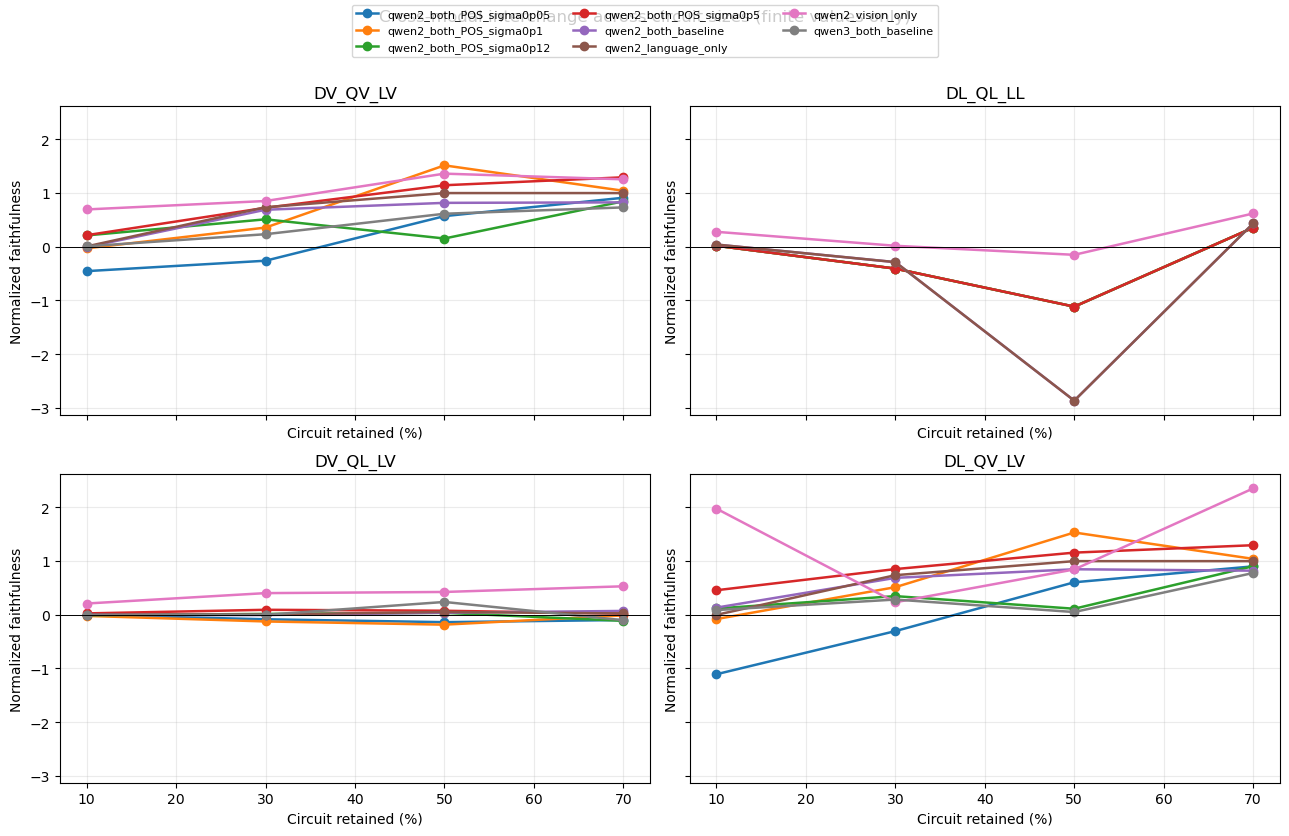

,variant,metric,circuit_percent,faithfulness_LD,finite_rows,undefined_rows
0,qwen2_both_POS_sigma0p05,DR_QL_LL,NaN,0.900612,5,0
1,qwen2_both_POS_sigma0p05,DV_QL_LL,NaN,-0.536275,5,0
2,qwen2_both_POS_sigma0p05,DR_QV_LV,NaN,1.000880,5,0
3,qwen2_both_POS_sigma0p05,DL_QL_LR,NaN,0.351682,5,0
4,qwen2_both_POS_sigma0p05,DL_QL_LV,NaN,0.351682,5,0
...,...,...,...,...,...,...
100,qwen3_both_baseline,DL_QL_LR,NaN,0.616386,5,0
101,qwen3_both_baseline,DL_QV_LV,NaN,0.775932,5,0
102,qwen3_both_baseline,DR_QV_LV,NaN,0.793693,5,0
103,qwen3_both_baseline,DV_QL_LL,NaN,0.504688,5,0


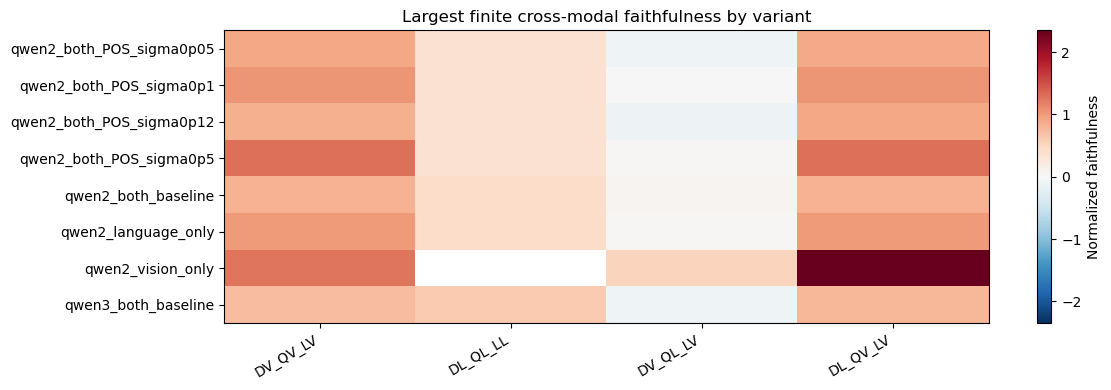

,model,pair,group,target,n,correct,accuracy
0,Qwen2-VL,goal_vs_corner,overall,all,97,74,0.762887
1,Qwen2-VL,goal_vs_corner,target,GOAL,50,47,0.940000
2,Qwen2-VL,goal_vs_corner,target,CORNER/THROW-IN,47,27,0.574468
3,Qwen2-VL,goal_vs_shot,overall,all,99,61,0.616162
4,Qwen2-VL,goal_vs_shot,target,GOAL,50,24,0.480000
5,Qwen2-VL,goal_vs_shot,target,SHOT-ON-TARGET,49,37,0.755102
6,Qwen2-VL,corner_vs_shot,overall,all,96,66,0.687500
7,Qwen2-VL,corner_vs_shot,target,CORNER/THROW-IN,47,29,0.617021
8,Qwen2-VL,corner_vs_shot,target,SHOT-ON-TARGET,49,37,0.755102
9,Qwen3-VL,goal_vs_corner,overall,all,97,50,0.515464


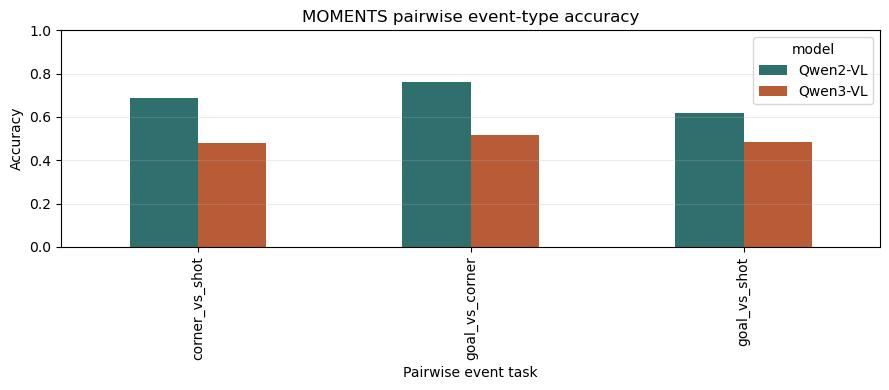

,sigma,n,correct,accuracy
0,0.05,146,126,0.863014
1,0.10,146,126,0.863014
2,0.50,146,126,0.863014


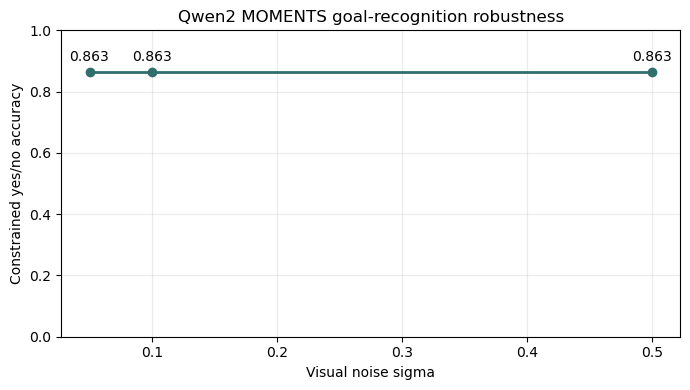

Future-run figures and tables saved to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results/new_experiment_variants/future_runs


In [36]:
# This cell is safe to rerun as additional Snellius outputs arrive.
FUTURE_OUTPUT_DIR = VARIANT_OUTPUT_DIR / 'future_runs'
FUTURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Cross-modal outputs from the new circuit-size sweep.
future_cross_rows = []
for variant, result_dir in EXPERIMENT_VARIANTS.items():
    cross_dir = result_dir / 'cross_modality'
    for path in sorted(cross_dir.rglob('faithfulness_nodes_cross_interchanges_LD_*.pt')):
        rows = cross_values_to_rows(variant, path)
        pair_match = re.search(r'l(\d+)_vl(\d+)$', path.parent.name)
        pair = pair_match.group(0) if pair_match else None
        l_percent = float(pair_match.group(1)) / 100.0 if pair_match else float('nan')
        vl_percent = float(pair_match.group(2)) / 100.0 if pair_match else float('nan')
        for row in rows:
            row['circuit_pair'] = pair
            row['l_percent'] = l_percent
            row['vl_percent'] = vl_percent
        future_cross_rows.extend(rows)

future_cross_df = pd.DataFrame(future_cross_rows)
if future_cross_df.empty:
    print('No cross-modal outputs found for the configured variants yet.')
else:
    future_cross_df['finite'] = np.isfinite(future_cross_df['faithfulness_LD'])
    # New sweep jobs write one scalar payload per lXXX_vlXXX folder.
    # Use VL retention as the x-axis for those scalar points.
    future_cross_df['plot_percent'] = future_cross_df['circuit_percent']
    scalar_mask = future_cross_df['plot_percent'].isna() & future_cross_df['vl_percent'].notna()
    future_cross_df.loc[scalar_mask, 'plot_percent'] = future_cross_df.loc[scalar_mask, 'vl_percent'] * 100.0
    future_cross_df['undefined'] = ~future_cross_df['finite']
    future_cross_df.to_csv(FUTURE_OUTPUT_DIR / 'cross_modal_all_runs.csv', index=False)
    cross_diagnostics = (future_cross_df.groupby(['variant', 'metric'], as_index=False)
        .agg(rows=('faithfulness_LD', 'size'), finite_rows=('finite', 'sum'),
             undefined_rows=('undefined', 'sum')))
    display(cross_diagnostics)
    cross_diagnostics.to_csv(FUTURE_OUTPUT_DIR / 'cross_modal_diagnostics.csv', index=False)

    key_metrics = ['DV_QV_LV', 'DL_QL_LL', 'DV_QL_LV', 'DL_QV_LV']
    plot_df = future_cross_df[future_cross_df['metric'].isin(key_metrics)].copy()
    plot_df = plot_df[plot_df['finite'] & plot_df['plot_percent'].notna()].copy()
    if not plot_df.empty:
        fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
        for ax, metric in zip(axes.ravel(), key_metrics):
            metric_df = plot_df[plot_df['metric'].eq(metric)]
            for variant, table in metric_df.groupby('variant'):
                table = table.sort_values('plot_percent')
                ax.plot(table['plot_percent'], table['faithfulness_LD'], marker='o', linewidth=1.8, label=variant)
            ax.axhline(0, color='black', linewidth=0.7)
            ax.set_title(metric)
            ax.set_xlabel('Circuit retained (%)')
            ax.set_ylabel('Normalized faithfulness')
            ax.grid(alpha=0.25)
        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=8)
        fig.suptitle('Cross-modal interchange across circuit sizes (finite values only)', y=1.04)
        fig.tight_layout()
        fig.savefig(FUTURE_OUTPUT_DIR / 'cross_modal_circuit_size_curves.png', dpi=200, bbox_inches='tight')
        plt.show()
    else:
        print('No cross-modal payload currently contains a finite percentage axis.')

    # Largest finite point per variant and metric, with undefined counts retained.
    finite_final = future_cross_df[future_cross_df['finite'] & future_cross_df['plot_percent'].notna()].sort_values('plot_percent')
    if not finite_final.empty:
        final_cross = finite_final.groupby(['variant', 'metric'], as_index=False).tail(1).copy()
        final_cross = final_cross.merge(cross_diagnostics, on=['variant', 'metric'], suffixes=('', '_diagnostic'))
        display(final_cross[['variant', 'metric', 'circuit_percent', 'faithfulness_LD', 'finite_rows', 'undefined_rows']])
        final_cross.to_csv(FUTURE_OUTPUT_DIR / 'cross_modal_final_finite.csv', index=False)
        pivot = final_cross.pivot(index='variant', columns='metric', values='faithfulness_LD').reindex(columns=key_metrics)
        fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(pivot))))
        vmax = max(float(np.nanmax(np.abs(pivot.to_numpy(dtype=float)))), 1e-6)
        image = ax.imshow(pivot.to_numpy(dtype=float), aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha='right')
        ax.set_yticks(range(len(pivot.index)), pivot.index)
        ax.set_title('Largest finite cross-modal faithfulness by variant')
        fig.colorbar(image, ax=ax, label='Normalized faithfulness')
        fig.tight_layout()
        fig.savefig(FUTURE_OUTPUT_DIR / 'cross_modal_final_finite_heatmap.png', dpi=200, bbox_inches='tight')
        plt.show()

# Pairwise event-type behavior for both models.
PAIRWISE_FILES = {
    'Qwen2-VL': RESULTS_ROOT / 'qwen2-7b-vl-instruct/behavior_event_type_pairwise_clean_summary.csv',
    'Qwen3-VL': RESULTS_ROOT / 'qwen3-8b-vl-instruct/behavior_event_type_pairwise_clean_summary.csv',
}
pairwise_rows = []
for model, path in PAIRWISE_FILES.items():
    if not path.exists():
        print(f'Missing pairwise behavior summary for {model}: {path}')
        continue
    table = pd.read_csv(path)
    table.insert(0, 'model', model)
    pairwise_rows.append(table)
if pairwise_rows:
    pairwise_df = pd.concat(pairwise_rows, ignore_index=True)
    display(pairwise_df)
    pairwise_df.to_csv(BEHAVIOR_OUTPUT_DIR / 'behavior_event_type_pairwise_summary_all_models.csv', index=False)
    pair_col = next((c for c in ['pair', 'task', 'comparison'] if c in pairwise_df.columns), None)
    acc_col = next((c for c in ['accuracy', 'constrained_accuracy'] if c in pairwise_df.columns), None)
    if pair_col and acc_col:
        # The summary has one overall row plus target-specific rows per pair.
        # Filter to one row per pair/model before pivoting for the plot.
        plot_table = pairwise_df[pairwise_df['group'].eq('overall')].copy() if 'group' in pairwise_df.columns else pairwise_df.copy()
        plot_table[acc_col] = pd.to_numeric(plot_table[acc_col], errors='coerce')
        ax = plot_table.pivot(index=pair_col, columns='model', values=acc_col).plot(kind='bar', figsize=(9, 4), color=['#2F6F6D', '#B85C38'])
        ax.set_ylim(0, 1.0)
        ax.set_ylabel('Accuracy')
        ax.set_xlabel('Pairwise event task')
        ax.set_title('MOMENTS pairwise event-type accuracy')
        ax.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.savefig(BEHAVIOR_OUTPUT_DIR / 'behavior_event_type_pairwise_qwen2_vs_qwen3.png', dpi=200, bbox_inches='tight')
        plt.show()
else:
    print('No pairwise event-type summaries found yet.')

# Qwen2 clean behavioral robustness for the sigma datasets that were run.
sigma_behavior_rows = []
for sigma in ['0p05', '0p1', '0p5']:
    path = RESULTS_ROOT / f'qwen2-7b-vl-instruct/behavior_clean_sigma{sigma}.csv'
    if not path.exists():
        print(f'Missing sigma behavior CSV: {path}')
        continue
    table = pd.read_csv(path)
    table['sigma'] = float(sigma.replace('p', '.'))
    sigma_behavior_rows.append(table)
if sigma_behavior_rows:
    sigma_behavior_df = pd.concat(sigma_behavior_rows, ignore_index=True)
    sigma_summary, sigma_confusion = summarize_classification(
        sigma_behavior_df, model='Qwen2-VL', task='goal_clean_sigma',
        target_col='target', pred_col='prediction_constrained_yes_no',
        correct_col='constrained_correct')
    # Add sigma to the summary using the same files, rather than pooling examples.
    sigma_overall = []
    for sigma, table in sigma_behavior_df.groupby('sigma'):
        sigma_overall.append({'sigma': sigma, 'n': len(table),
            'correct': int(table['constrained_correct'].astype(bool).sum()),
            'accuracy': float(table['constrained_correct'].astype(bool).mean())})
    sigma_overall_df = pd.DataFrame(sigma_overall).sort_values('sigma')
    display(sigma_overall_df)
    sigma_overall_df.to_csv(BEHAVIOR_OUTPUT_DIR / 'behavior_sigma_robustness_summary.csv', index=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sigma_overall_df['sigma'], sigma_overall_df['accuracy'], marker='o', linewidth=2, color='#2F6F6D')
    for row in sigma_overall_df.itertuples(index=False):
        ax.annotate(f'{row.accuracy:.3f}', (row.sigma, row.accuracy), xytext=(0, 8), textcoords='offset points', ha='center')
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('Visual noise sigma')
    ax.set_ylabel('Constrained yes/no accuracy')
    ax.set_title('Qwen2 MOMENTS goal-recognition robustness')
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(BEHAVIOR_OUTPUT_DIR / 'behavior_sigma_robustness_qwen2.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('No Qwen2 sigma behavior CSVs found yet.')

print('Future-run figures and tables saved to:', FUTURE_OUTPUT_DIR.resolve())